# Bayesian Inference of LLM-as-a-Judge True Pass Rate
## From First Principles — Uncertainty, Priors, and Maximum Entropy

---

### The Problem

You've deployed an **LLM-as-a-Judge** to evaluate production traces. It classifies each trace as PASS or FAIL. You observe $K$ passes out of $N$ traces and naively compute $\hat{\theta} = K/N$.

**This is wrong.** The judge is imperfect. It has a false positive rate (passes traces that should fail) and a false negative rate (fails traces that should pass). The raw $K/N$ is a *biased mixture* of the true pass rate and the judge's errors.

> **The question**: Given a human-labelled validation set that measures judge accuracy, what is the **true underlying pass rate** $\theta$ — along with honest uncertainty?

**Key assumption — humans are perfect oracles.**  
We treat human labels as ground truth: if a human says PASS, the trace truly passes. This is the standard assumption in annotation pipelines and simplifies the model considerably.

In reality, humans also make mistakes and disagree. If you want to quantify *human* uncertainty too, you would need multiple annotators per example and a richer model — for example, **Item Response Theory (IRT)**, which jointly estimates annotator reliability and true item difficulty. That is a natural extension of this model but outside our scope here. For now, we trust the human.

---

### Why Bayesian?

Bayesian inference gives you a **full posterior distribution** over every unknown. Not just "the pass rate is about 70%" — but *exactly how uncertain* you should be, given your data and prior knowledge.

It forces you to be explicit about three things:
- What you knew **before** seeing data → the **prior**
- How the data updates that knowledge → the **likelihood**
- What you now believe → the **posterior**

---

### What This Notebook Covers

| Section | What you learn |
|---------|----------------|
| Mathematical Framework | Generative model, law of total probability, Bayes' theorem, marginalisation |
| Prior Predictive Check | What your priors imply *before* seeing any data |
| Grid Approximation | Explicit 3D marginalisation — the glass-box approach |
| MCMC with PyMC | Same model, scalable NUTS sampler |
| Hypothesis A | Small data: does an informative prior help? |
| Hypothesis B | Large data: do priors matter at all? |
| Posterior Predictive Check | Does the fitted model reproduce what we observed? |

## Part 1: Mathematical Framework

---

### 1.1 Variables — and What Each Word Means

Before the math, let's be precise about vocabulary. These three terms are often confused:

| Term | Meaning | In our model |
|------|---------|-------------|
| **Observed** | Directly counted from data. No inference needed. | $K,\; K_{PP},\; K_{NN}$ |
| **Parameter** | Unknown quantity with a **prior**. Directly inferred — the free variables of the model. All parameters are latent. | $\theta,\; \text{TPR},\; \text{TNR}$ |
| **Deterministic** | Computed from parameters via a formula. No prior, not directly inferred — but **inherits a posterior** from its inputs. Latent in the sense that we never observe it directly. | $p_{\text{judge}}$ |

> **Rule of thumb**: if you write $\sim \text{Beta}(\ldots)$ for it — it is a **parameter**. If you write $=$ — it is **deterministic**.

The full hierarchy:

```
Observed          K, K_PP, K_NN        ← directly counted from data
  └── Latent (unobserved)
        ├── Parameters    θ, TPR, TNR   ← have priors, directly inferred
        └── Deterministic p_judge       ← computed from parameters, no prior,
                                           but inherits a posterior from them
```

This distinction matters in PyMC: parameters become `pm.Beta(...)`, deterministic nodes become `pm.Deterministic(...)`. The sampler only explores the parameter space — deterministic nodes come along for free.

---

### 1.2 The Bridge — Law of Total Probability

What is the probability the judge says PASS on a random production trace?

$$p_{\text{judge}} \;=\; P(\text{Judge=PASS})$$

$$= P(\text{Judge=PASS} \mid \text{True=PASS})\cdot P(\text{True=PASS}) \;+\; P(\text{Judge=PASS} \mid \text{True=FAIL})\cdot P(\text{True=FAIL})$$

$$\boxed{p_{\text{judge}} \;=\; \theta \cdot \text{TPR} \;+\; (1-\theta)\cdot(1-\text{TNR})}$$

The judge sees PASS for **two distinct reasons**:
1. The trace **truly passes** (prob $\theta$) and the judge **correctly identifies it** ($\text{TPR}$)
2. The trace **truly fails** (prob $1-\theta$) but the judge **incorrectly passes it** (False Positive Rate $= 1-\text{TNR}$)

This is why $K/N \neq \theta$. The naive estimate conflates signal with noise.

---

### 1.3 Generative Model

**Priors** — what we believe before seeing data:
$$\theta \sim \text{Beta}(\alpha_\theta,\, \beta_\theta)$$
$$\text{TPR} \sim \text{Beta}(\alpha_{\text{TPR}},\, \beta_{\text{TPR}})$$
$$\text{TNR} \sim \text{Beta}(\alpha_{\text{TNR}},\, \beta_{\text{TNR}})$$

**Likelihoods** — how data is generated given the parameters:

*Validation set (tells us about judge accuracy):*
$$K_{PP} \sim \text{Binomial}(N_+,\;\text{TPR})$$
$$K_{NN} \sim \text{Binomial}(N_-,\;\text{TNR})$$

*Production traces (what we observe every day):*
$$K \;\sim\; \text{Binomial}\!\left(N,\;\; \theta\cdot\text{TPR} + (1-\theta)\cdot(1-\text{TNR})\right)$$

---

### 1.4 Bayes' Theorem

$$\underbrace{P(\theta,\,\text{TPR},\,\text{TNR} \mid \text{data})}_{\text{posterior}} \;\propto\;
\underbrace{P(K \mid N,\, p_{\text{judge}})}_{\text{production likelihood}}
\;\cdot\;
\underbrace{P(K_{PP} \mid N_+,\,\text{TPR})\cdot P(K_{NN} \mid N_-,\,\text{TNR})}_{\text{validation likelihoods}}
\;\cdot\;
\underbrace{P(\theta)\cdot P(\text{TPR})\cdot P(\text{TNR})}_{\text{priors}}$$

The result is a **joint posterior** — a single probability distribution over all three parameters simultaneously.

**Why do we need the validation likelihoods if p_judge already contains TPR and TNR?**

The production likelihood gives you one constraint: $K \approx N \cdot p_{\text{judge}}$. But $p_{\text{judge}} = \theta \cdot \text{TPR} + (1-\theta)(1-\text{TNR})$ is one number built from three unknowns. Production data alone cannot separate them — the model is unidentified. The validation likelihoods independently pin down TPR and TNR, allowing the production likelihood to finally isolate $\theta$.

#### Joint vs Sequential — Two Routes, Same Answer

The joint posterior can be decomposed via the **chain rule of probability**:

$$P(\theta,\,\text{TPR},\,\text{TNR} \mid \text{data}) = P(\theta \mid \text{TPR},\,\text{TNR},\,\text{data}) \cdot \underbrace{P(\text{TPR} \mid \text{data}) \cdot P(\text{TNR} \mid \text{data})}_{\text{TPR} \perp \text{TNR given data}}$$

This reveals a **sequential route** that gives the identical final answer:

| Step | Sequential route | Joint route |
|------|-----------------|-------------|
| 1 | Compute $P(\text{TPR} \mid K_{PP})$ from validation positives alone | — |
| 2 | Compute $P(\text{TNR} \mid K_{NN})$ from validation negatives alone | — |
| 3 | Use those posteriors as effective priors; integrate out TPR, TNR to get $P(\theta \mid K)$ | Compute full joint; marginalise |

In the sequential route you **never form the joint** — you only ever compute $P(\theta \mid \text{all data})$ directly through a chain of simpler steps.

**Both routes give the same marginal posterior for $\theta$.** The joint approach computes all three posteriors simultaneously. The grid approximation we build next is the joint approach — and marginalisation falls out naturally as summing over array dimensions.

---

### 1.5 Marginalisation

To reason about any single parameter, we must **integrate out** the other two.  
This is not optional — it is the honest accounting of all uncertainty.

$$P(\theta \mid \text{data}) = \iint P(\theta,\,\text{TPR},\,\text{TNR} \mid \text{data})\; d\,\text{TPR}\; d\,\text{TNR}$$

$$P(\text{TPR} \mid \text{data}) = \iint P(\theta,\,\text{TPR},\,\text{TNR} \mid \text{data})\; d\,\theta\; d\,\text{TNR}$$

$$P(\text{TNR} \mid \text{data}) = \iint P(\theta,\,\text{TPR},\,\text{TNR} \mid \text{data})\; d\,\theta\; d\,\text{TPR}$$

A naive approach would point-estimate TPR and TNR from the validation set and plug them in. **This underestimates uncertainty in $\theta$** — especially when the validation set is small.  
Marginalisation propagates the uncertainty in TPR and TNR forward into $\theta$.

In grid approximation, these integrals become **literal array summations** over the corresponding dimensions. This makes the concept concrete and inspectable.

---

### 1.6 Why Beta–Binomial? Maximum Entropy

The choice of Beta priors and Binomial likelihoods is not arbitrary. It follows from the **Maximum Entropy principle** (Jaynes, 1957):

> Among all distributions consistent with your constraints, choose the one with **maximum entropy** — the one that makes the fewest additional assumptions.

- **Binomial**: MaxEnt for $n$ binary trials with fixed success probability $p$. Assumes nothing beyond the trial structure and independence.
- **Beta**: MaxEnt for a probability $p \in [0,1]$ given constraints on its mean and concentration. It is also the conjugate prior for the Binomial — the posterior is again Beta, which is analytically elegant.

Bayesian inference under MaxEnt is **epistemically honest**: it encodes exactly what you know, nothing more.

## Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import beta as beta_dist, binom
from scipy.special import logsumexp
import pymc as pm
import arviz as az
import logging
import warnings

warnings.filterwarnings('ignore')

# ── Suppress PyMC/numba INFO messages (they render red in Jupyter stderr) ─────
logging.getLogger("pymc").setLevel(logging.ERROR)
logging.getLogger("numba").setLevel(logging.ERROR)
logging.getLogger("pytensor").setLevel(logging.ERROR)

# ── Plotting style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        120,
    'font.size':         11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'figure.facecolor':  'white',
})

print(f'NumPy  {np.__version__}')
print(f'PyMC   {pm.__version__}')
print(f'ArviZ  {az.__version__}')


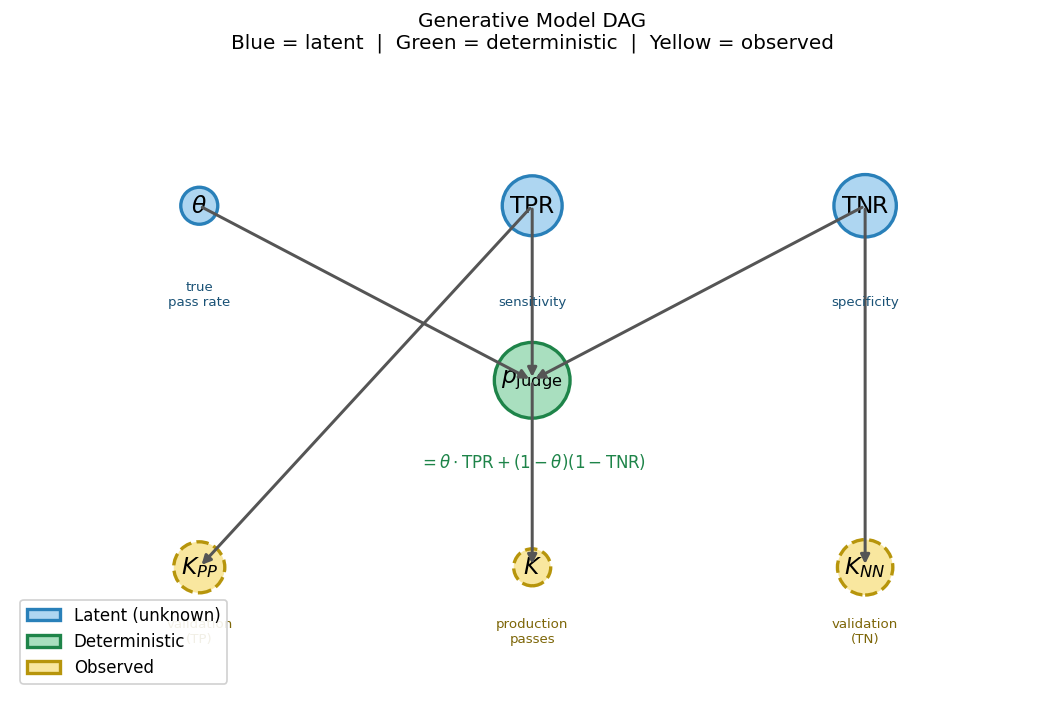

In [3]:
# ── Directed Acyclic Graph (DAG) of the generative model ────────
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# ── Node definitions: (x, y, label, style) ───────────────────────
LATENT   = dict(boxstyle="circle", fc="#AED6F1", ec="#2980B9", lw=2)    # blue  = latent
DET      = dict(boxstyle="circle", fc="#A9DFBF", ec="#1E8449", lw=2)    # green = deterministic
OBS      = dict(boxstyle="circle", fc="#F9E79F", ec="#B7950B", lw=2,    # yellow = observed
                linestyle="--")

nodes = {
    "theta":   (0.18, 0.78, r"$\theta$",          LATENT),
    "tpr":     (0.50, 0.78, r"$\mathrm{TPR}$",    LATENT),
    "tnr":     (0.82, 0.78, r"$\mathrm{TNR}$",    LATENT),
    "pjudge":  (0.50, 0.50, r"$p_{\mathrm{judge}}$", DET),
    "kpp":     (0.18, 0.20, r"$K_{PP}$",          OBS),
    "kprod":   (0.50, 0.20, r"$K$",               OBS),
    "knn":     (0.82, 0.20, r"$K_{NN}$",          OBS),
}

for key, (x, y, label, style) in nodes.items():
    ax.annotate(label, xy=(x, y), fontsize=14, ha='center', va='center',
                bbox=style)

# ── Edges ────────────────────────────────────────────────────────
edges = [
    ("theta",  "pjudge"),
    ("tpr",    "pjudge"),
    ("tnr",    "pjudge"),
    ("pjudge", "kprod"),
    ("tpr",    "kpp"),
    ("tnr",    "knn"),
]

arrowprops = dict(arrowstyle="-|>", color="#555555", lw=1.8,
                  connectionstyle="arc3,rad=0.0")

for src, dst in edges:
    x0, y0 = nodes[src][0], nodes[src][1]
    x1, y1 = nodes[dst][0], nodes[dst][1]
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=arrowprops)

# ── Legend ────────────────────────────────────────────────────────
legend_items = [
    plt.Rectangle((0,0),1,1, fc="#AED6F1", ec="#2980B9", lw=2,  label="Latent (unknown)"),
    plt.Rectangle((0,0),1,1, fc="#A9DFBF", ec="#1E8449", lw=2,  label="Deterministic"),
    plt.Rectangle((0,0),1,1, fc="#F9E79F", ec="#B7950B", lw=2,  label="Observed"),
]
ax.legend(handles=legend_items, loc="lower left", fontsize=10, framealpha=0.9)

# ── Annotations ───────────────────────────────────────────────────
ax.text(0.18, 0.62, "true\npass rate", ha='center', fontsize=8, color="#1A5276")
ax.text(0.50, 0.62, "sensitivity", ha='center', fontsize=8, color="#1A5276")
ax.text(0.82, 0.62, "specificity", ha='center', fontsize=8, color="#1A5276")
ax.text(0.50, 0.36, r"$= \theta \cdot \mathrm{TPR} + (1-\theta)(1-\mathrm{TNR})$",
        ha='center', fontsize=10, color="#1E8449")
ax.text(0.18, 0.08, "validation\n(TP)", ha='center', fontsize=8, color="#7D6608")
ax.text(0.50, 0.08, "production\npasses", ha='center', fontsize=8, color="#7D6608")
ax.text(0.82, 0.08, "validation\n(TN)", ha='center', fontsize=8, color="#7D6608")

ax.set_title("Generative Model DAG\nBlue = latent  |  Green = deterministic  |  Yellow = observed",
             fontsize=12, pad=12)

plt.tight_layout()
plt.show()

## Master Configuration

All experiments are driven from this single cell.  
**Change `ACTIVE_SCENARIO` to switch between experiments — nothing else needs to change.**

| Scenario | Data size | Priors | Purpose |
|---|---|---|---|
| `baseline` | moderate | flat | Default starting point |
| `small_flat` | small | flat | Hypothesis A — reference |
| `small_informative` | small | informative | Hypothesis A — experiment |
| `large_flat` | large | flat | Hypothesis B — reference |
| `large_informative` | large | informative | Hypothesis B — should converge to `large_flat` |

In [4]:
# ================================================================
#  MASTER CONFIGURATION
#  ↓ Change this one line to switch between all experiments ↓
# ================================================================
ACTIVE_SCENARIO = "baseline"
# ================================================================

SCENARIOS = {

    # ------------------------------------------------------------------
    # Default: moderate data, flat priors
    # ------------------------------------------------------------------
    "baseline": {
        "description": "Baseline — moderate data, flat (non-informative) priors",
        # Ground truth used only for simulation (unknown in real life)
        "true_theta": 0.70,   # 70% of traces truly pass
        "true_tpr":   0.82,   # judge correctly passes 82% of true passes
        "true_tnr":   0.79,   # judge correctly fails 79% of true fails
        # Validation set
        "n_val_pos":  50,     # human-labelled positives
        "n_val_neg":  50,     # human-labelled negatives
        # Production set
        "N_prod":     200,
        # Priors: Beta(alpha, beta)
        # Beta(1,1) = Uniform[0,1] — completely flat, encodes no prior knowledge
        "theta_prior": (1, 1),
        "tpr_prior":   (1, 1),
        "tnr_prior":   (1, 1),
    },

    # ------------------------------------------------------------------
    # Hypothesis A — small data, flat prior (wide posterior expected)
    # ------------------------------------------------------------------
    "small_flat": {
        "description": "Hypothesis A — small data + flat priors → wide, uncertain posteriors",
        "true_theta": 0.70, "true_tpr": 0.82, "true_tnr": 0.79,
        "n_val_pos":  10,   "n_val_neg": 10,
        "N_prod":     40,
        "theta_prior": (1, 1),
        "tpr_prior":   (1, 1),
        "tnr_prior":   (1, 1),
    },

    # ------------------------------------------------------------------
    # Hypothesis A — small data, informative prior (tighter posterior expected)
    # ------------------------------------------------------------------
    "small_informative": {
        "description": "Hypothesis A — small data + informative priors → tighter posteriors",
        "true_theta": 0.70, "true_tpr": 0.82, "true_tnr": 0.79,
        "n_val_pos":  10,   "n_val_neg": 10,
        "N_prod":     40,
        # Beta(8,2): mean = 8/(8+2) = 0.8, encodes knowledge that judge is ~80% accurate
        # Beta(3,2): mean = 3/(3+2) = 0.6, weakly informative for theta
        "theta_prior": (3, 2),
        "tpr_prior":   (8, 2),
        "tnr_prior":   (8, 2),
    },

    # ------------------------------------------------------------------
    # Hypothesis B — large data, flat prior
    # ------------------------------------------------------------------
    "large_flat": {
        "description": "Hypothesis B — large data + flat priors → data dominates",
        "true_theta": 0.70, "true_tpr": 0.82, "true_tnr": 0.79,
        "n_val_pos":  200,  "n_val_neg": 200,
        "N_prod":     1000,
        "theta_prior": (1, 1),
        "tpr_prior":   (1, 1),
        "tnr_prior":   (1, 1),
    },

    # ------------------------------------------------------------------
    # Hypothesis B — large data, informative prior (should converge to large_flat)
    # ------------------------------------------------------------------
    "large_informative": {
        "description": "Hypothesis B — large data + informative priors → same as large_flat (priors washed out)",
        "true_theta": 0.70, "true_tpr": 0.82, "true_tnr": 0.79,
        "n_val_pos":  200,  "n_val_neg": 200,
        "N_prod":     1000,
        "theta_prior": (3, 2),
        "tpr_prior":   (8, 2),
        "tnr_prior":   (8, 2),
    },
}

# Load active scenario
cfg = SCENARIOS[ACTIVE_SCENARIO]

print(f"Active scenario : {ACTIVE_SCENARIO}")
print(f"Description     : {cfg['description']}")
print()
print(f"Ground truth (simulation only)")
print(f"  θ   = {cfg['true_theta']}   ← true pass rate")
print(f"  TPR = {cfg['true_tpr']}   ← judge sensitivity")
print(f"  TNR = {cfg['true_tnr']}   ← judge specificity")
print()
print(f"Validation set  : N+ = {cfg['n_val_pos']}, N- = {cfg['n_val_neg']}")
print(f"Production      : N  = {cfg['N_prod']}")
print()
print(f"Priors")
print(f"  θ   ~ Beta{cfg['theta_prior']}")
print(f"  TPR ~ Beta{cfg['tpr_prior']}")
print(f"  TNR ~ Beta{cfg['tnr_prior']}")

Active scenario : baseline
Description     : Baseline — moderate data, flat (non-informative) priors

Ground truth (simulation only)
  θ   = 0.7   ← true pass rate
  TPR = 0.82   ← judge sensitivity
  TNR = 0.79   ← judge specificity

Validation set  : N+ = 50, N- = 50
Production      : N  = 200

Priors
  θ   ~ Beta(1, 1)
  TPR ~ Beta(1, 1)
  TNR ~ Beta(1, 1)


In [6]:

import ipywidgets as widgets
from IPython.display import display, clear_output

# ── Interactive scenario selector ─────────────────────────────────────────────
# Use the dropdown to switch scenario, then re-run all cells below.
# (MCMC is slow — the dropdown just sets the config, it does not auto-run inference.)

scenario_descriptions = {
    "baseline":          "N_val=50,  N_prod=200   | Flat priors     | Default starting point",
    "small_flat":        "N_val=10,  N_prod=40    | Flat priors     | H2: small data reference",
    "small_informative": "N_val=10,  N_prod=40    | Info priors     | H2: informative vs flat",
    "large_flat":        "N_val=200, N_prod=1000  | Flat priors     | H3: large data reference",
    "large_informative": "N_val=200, N_prod=1000  | Info priors     | H3: prior washes out",
}

dropdown = widgets.Dropdown(
    options=list(SCENARIOS.keys()),
    value=ACTIVE_SCENARIO,
    description="Scenario:",
    style={"description_width": "80px"},
    layout=widgets.Layout(width="340px"),
)
out = widgets.Output()

def on_change(change):
    global ACTIVE_SCENARIO, cfg
    if change["name"] == "value":
        ACTIVE_SCENARIO = change["new"]
        cfg = SCENARIOS[ACTIVE_SCENARIO]
        with out:
            clear_output(wait=True)
            c = cfg
            print(f"  Active scenario : {ACTIVE_SCENARIO}")
            print(f"  {scenario_descriptions[ACTIVE_SCENARIO]}")
            print(f"  ─────────────────────────────────────────────────────")
            print(f"  True θ={c['true_theta']}  TPR={c['true_tpr']}  TNR={c['true_tnr']}")
            print(f"  N_val_pos={c['n_val_pos']}  N_val_neg={c['n_val_neg']}  N_prod={c['N_prod']}")
            print(f"  θ prior=Beta{c['theta_prior']}  TPR prior=Beta{c['tpr_prior']}  TNR prior=Beta{c['tnr_prior']}")
            print(f"\n  ⚠  Re-run all cells below to apply the new scenario.")

dropdown.observe(on_change, names="value")

# Trigger display for the currently selected scenario
with out:
    c = cfg
    print(f"  Active scenario : {ACTIVE_SCENARIO}")
    print(f"  {scenario_descriptions[ACTIVE_SCENARIO]}")
    print(f"  ─────────────────────────────────────────────────────")
    print(f"  True θ={c['true_theta']}  TPR={c['true_tpr']}  TNR={c['true_tnr']}")
    print(f"  N_val_pos={c['n_val_pos']}  N_val_neg={c['n_val_neg']}  N_prod={c['N_prod']}")
    print(f"  θ prior=Beta{c['theta_prior']}  TPR prior=Beta{c['tpr_prior']}  TNR prior=Beta{c['tnr_prior']}")

display(widgets.VBox([dropdown, out]))


## Data Simulation

We simulate data from the true parameters defined in `cfg`.  
In a real deployment, this cell would be replaced by loading your actual validation set and production counts.

**Why simulate?** Because we know the ground truth, we can verify that the model
recovers the right answer. This is the gold standard for testing any statistical model.

In [7]:
rng = np.random.default_rng(seed=42)

# ── Validation set ───────────────────────────────────────────────
k_pp = rng.binomial(cfg["n_val_pos"], cfg["true_tpr"])   # Human=PASS, Judge=PASS  (true positive)
k_nn = rng.binomial(cfg["n_val_neg"], cfg["true_tnr"])   # Human=FAIL, Judge=FAIL  (true negative)
k_pf = cfg["n_val_pos"] - k_pp                           # Human=PASS, Judge=FAIL  (false negative)
k_fp = cfg["n_val_neg"] - k_nn                           # Human=FAIL, Judge=PASS  (false positive)
n_val_total = cfg["n_val_pos"] + cfg["n_val_neg"]

# ── Production set ───────────────────────────────────────────────
# Law of total probability: p_judge = θ·TPR + (1-θ)·(1-TNR)
p_judge_true = cfg["true_theta"] * cfg["true_tpr"] + (1 - cfg["true_theta"]) * (1 - cfg["true_tnr"])
K_prod       = rng.binomial(cfg["N_prod"], p_judge_true)
K_prod_fail  = cfg["N_prod"] - K_prod

# Bundle for downstream cells
data = {"k_pp": k_pp, "k_nn": k_nn, "K_prod": K_prod}

# ================================================================
# ABBREVIATION LEGEND
# ================================================================
print("ABBREVIATION LEGEND")
print("=" * 58)
print("  n_val_pos   total human-labelled PASS examples")
print("  n_val_neg   total human-labelled FAIL examples")
print("  k_pp        Human=PASS  AND  Judge=PASS   ← true positive")
print("  k_pf        Human=PASS  AND  Judge=FAIL   ← false negative")
print("  k_fp        Human=FAIL  AND  Judge=PASS   ← false positive")
print("  k_nn        Human=FAIL  AND  Judge=FAIL   ← true negative")
print("  N_prod      total production traces evaluated by judge")
print("  K_prod      traces where Judge said PASS in production")
print()

# ================================================================
# EXPERIMENT NARRATIVE
# ================================================================
print("EXPERIMENT SETUP")
print("=" * 58)
print(f"  Scenario  : [{ACTIVE_SCENARIO}]")
print(f"  {cfg['description']}")
print()
print(f"  Validation set : {n_val_total} total human-labelled examples")
print(f"                   {cfg['n_val_pos']} labelled PASS  |  {cfg['n_val_neg']} labelled FAIL")
print(f"  Production     : {cfg['N_prod']} traces evaluated by the judge")
print()

# ================================================================
# CONFUSION MATRIX  (validation set)
# ================================================================
print("JUDGE CONFUSION MATRIX  (validation set)")
print("=" * 58)
print(f"                          Judge=PASS   Judge=FAIL   Total")
print(f"  Human=PASS  (n={cfg['n_val_pos']:3d})       {k_pp:4d}         {k_pf:4d}       {cfg['n_val_pos']:4d}")
print(f"  Human=FAIL  (n={cfg['n_val_neg']:3d})       {k_fp:4d}         {k_nn:4d}       {cfg['n_val_neg']:4d}")
print(f"  Total       (n={n_val_total:3d})       {k_pp+k_fp:4d}         {k_pf+k_nn:4d}       {n_val_total:4d}")
print()
print(f"  Observed TPR = k_pp / n_val_pos = {k_pp}/{cfg['n_val_pos']} = {k_pp/cfg['n_val_pos']:.3f}   (true TPR = {cfg['true_tpr']})")
print(f"  Observed TNR = k_nn / n_val_neg = {k_nn}/{cfg['n_val_neg']} = {k_nn/cfg['n_val_neg']:.3f}   (true TNR = {cfg['true_tnr']})")
print()

# ================================================================
# PRODUCTION SUMMARY
# ================================================================
print("PRODUCTION TRACES")
print("=" * 58)
print(f"  Total traces          N     = {cfg['N_prod']}")
print(f"  Judge = PASS          K     = {K_prod}  ({K_prod/cfg['N_prod']:.1%})  ← observed judge pass rate")
print(f"  Judge = FAIL          N-K   = {K_prod_fail}  ({K_prod_fail/cfg['N_prod']:.1%})")
print()
print(f"  Observed judge pass rate  K/N = {K_prod/cfg['N_prod']:.3f}  ← biased, do not use as θ")
print(f"  True p_judge                  = {p_judge_true:.3f}  ← what judge actually observes")
print(f"  True pass rate          θ     = {cfg['true_theta']:.3f}  ← what we want to recover")
print(f"  Bias = K/N - θ                = {K_prod/cfg['N_prod'] - cfg['true_theta']:+.3f}")

ABBREVIATION LEGEND
  n_val_pos   total human-labelled PASS examples
  n_val_neg   total human-labelled FAIL examples
  k_pp        Human=PASS  AND  Judge=PASS   ← true positive
  k_pf        Human=PASS  AND  Judge=FAIL   ← false negative
  k_fp        Human=FAIL  AND  Judge=PASS   ← false positive
  k_nn        Human=FAIL  AND  Judge=FAIL   ← true negative
  N_prod      total production traces evaluated by judge
  K_prod      traces where Judge said PASS in production

EXPERIMENT SETUP
  Scenario  : [baseline]
  Baseline — moderate data, flat (non-informative) priors

  Validation set : 100 total human-labelled examples
                   50 labelled PASS  |  50 labelled FAIL
  Production     : 200 traces evaluated by the judge

JUDGE CONFUSION MATRIX  (validation set)
                          Judge=PASS   Judge=FAIL   Total
  Human=PASS  (n= 50)         39           11         50
  Human=FAIL  (n= 50)         10           40         50
  Total       (n=100)         49           51  

## Part 2: Prior Predictive Check

Before fitting the model, we ask: **what does the model expect before seeing any data?**

This is the **prior predictive distribution** — we sample parameters from their priors, compute $p_{\text{judge}}$ via the law of total probability, then simulate $K$ from $\text{Binomial}(N, p_{\text{judge}})$.

### Why do this?

1. **Sanity check your priors.** If the prior predictive implies impossible or absurd values of $K$ — say, 0 or $N$ almost always — your priors are poorly chosen regardless of what they look like in isolation.
2. **See what "non-informative" actually means.** A flat $\text{Beta}(1,1)$ prior on each parameter sounds harmless. But when three flat priors combine through the law of total probability, the implied $p_{\text{judge}}$ is not flat — it gets pushed toward 0.5. This is a subtle but important effect.
3. **Set expectations before inference.** The observed $K$ should sit comfortably within the bulk of the prior predictive. If it falls in the tail, something is off.

> The prior predictive check is **not about being right** — it is about being *reasonable*. We are asking: does my model, before seeing data, at least live in the same universe as the data?

---

### What Is the Prior Predictive, Mathematically?

The prior predictive is **average likelihood over the prior**:

$$p(\tilde{y}) = \int p(\tilde{y} \mid \theta) \cdot p(\theta) \; d\theta$$

At every point $\theta$ in parameter space, the likelihood $p(\tilde{y} \mid \theta)$ gives a full distribution over possible data values $\tilde{y}$. We average those distributions weighted by the prior. The result: the probability of each possible dataset *before seeing any data*.

This looks identical to the **denominator of Bayes' theorem**:

$$p(y) = \int p(y \mid \theta) \cdot p(\theta) \; d\theta$$

Same formula — but a completely different question:

| | What varies | What is fixed | Result |
|--|--|--|--|
| **Bayes denominator** | $\theta$ | observed $y$ | **scalar** — normalising constant |
| **Prior predictive** | $\theta$ and $\tilde{y}$ | nothing | **distribution** over possible data |
| **Posterior predictive** | $\theta$ and $\tilde{y}$ | observed $y$ (via posterior) | **distribution** over future data |

In the denominator, $y$ is the data you already observed — fixed. The integral collapses to one number that normalises the posterior. In the prior predictive, $\tilde{y}$ is a free variable — you evaluate the integral for every possible $\tilde{y}$ and trace out a full distribution.

**How the code implements this integral exactly:**

```python
# Step 1: sample θ from the prior (one point in parameter space)
theta_s = rng.beta(alpha_theta, beta_theta)

# Step 2: at this θ, the likelihood tells you which K values are probable
K_pred = rng.binomial(N, p_judge(theta_s, tpr_s, tnr_s))

# Step 3: repeat 20,000 times and histogram
# → each draw contributes one likelihood-weighted "vote" for a K value
# → the histogram IS the integral made concrete
```

This Monte Carlo approximation of the integral is exact in the limit of infinite samples — and already very accurate at 20,000.

---

### Key Insight: Flat Priors on Parameters ≠ Flat Prior on Derived Quantities

Look at the plots below. TPR and TNR have flat $\text{Beta}(1,1)$ priors — completely uniform, every value equally likely. But $p_{\text{judge}}$ comes out **bell-shaped**, concentrated near 0.5.

Why? Because $p_{\text{judge}}$ is a nonlinear combination of three independent uniforms:

$$p_{\text{judge}} = \theta \cdot \text{TPR} + (1-\theta)(1-\text{TNR})$$

By independence:

$$E[p_{\text{judge}}] = E[\theta]\cdot E[\text{TPR}] + E[1-\theta]\cdot E[1-\text{TNR}] = 0.5 \times 0.5 + 0.5 \times 0.5 = 0.50$$

The **variance shrinks** — the product of two uniform variables has less spread than either alone, and summing two such products shrinks it further. Bell shape centred at 0.5, despite no individual prior having that shape.

**The practical consequence**: a "flat" prior on $(\theta, \text{TPR}, \text{TNR})$ is actually *informative* on $p_{\text{judge}}$ — it says the judge pass rate is probably near 50%. This may or may not match your domain knowledge.

**This is why prior predictive checks are essential.** Priors that look innocent parameter-by-parameter can impose strong implicit beliefs on the quantities you actually care about. Always check what your priors imply at the level of observables.

> **Historical note**: This problem — that "uninformative" priors are not invariant to reparameterisation — motivated Harold Jeffreys to develop the **Jeffreys prior** (1946), which is constructed to remain uninformative under any smooth transformation of the parameters.

PRIOR PREDICTIVE SUMMARY
  Priors:  θ~Beta(1, 1)  TPR~Beta(1, 1)  TNR~Beta(1, 1)

  Parameter priors — what does the prior believe?
  Parameter     Mean  89% CI                Interpretation
  ------------------------------------------------------------
  θ            0.501  [0.054, 0.945]          prior belief about true pass rate
  TPR          0.499  [0.053, 0.946]          prior belief about judge sensitivity
  TNR          0.500  [0.057, 0.944]          prior belief about judge specificity
  p_judge      0.499  [0.126, 0.873]          implied observed judge pass rate

  Observable prior predictive checks
  Observable    Observed  89% Prior CI        Check
  ------------------------------------------------------------
  K_PP                39  [    2,    48]           ✓ within 89% CI
  K_NN                40  [    2,    48]           ✓ within 89% CI
  K (prod)           137  [   24,   175]           ✓ within 89% CI


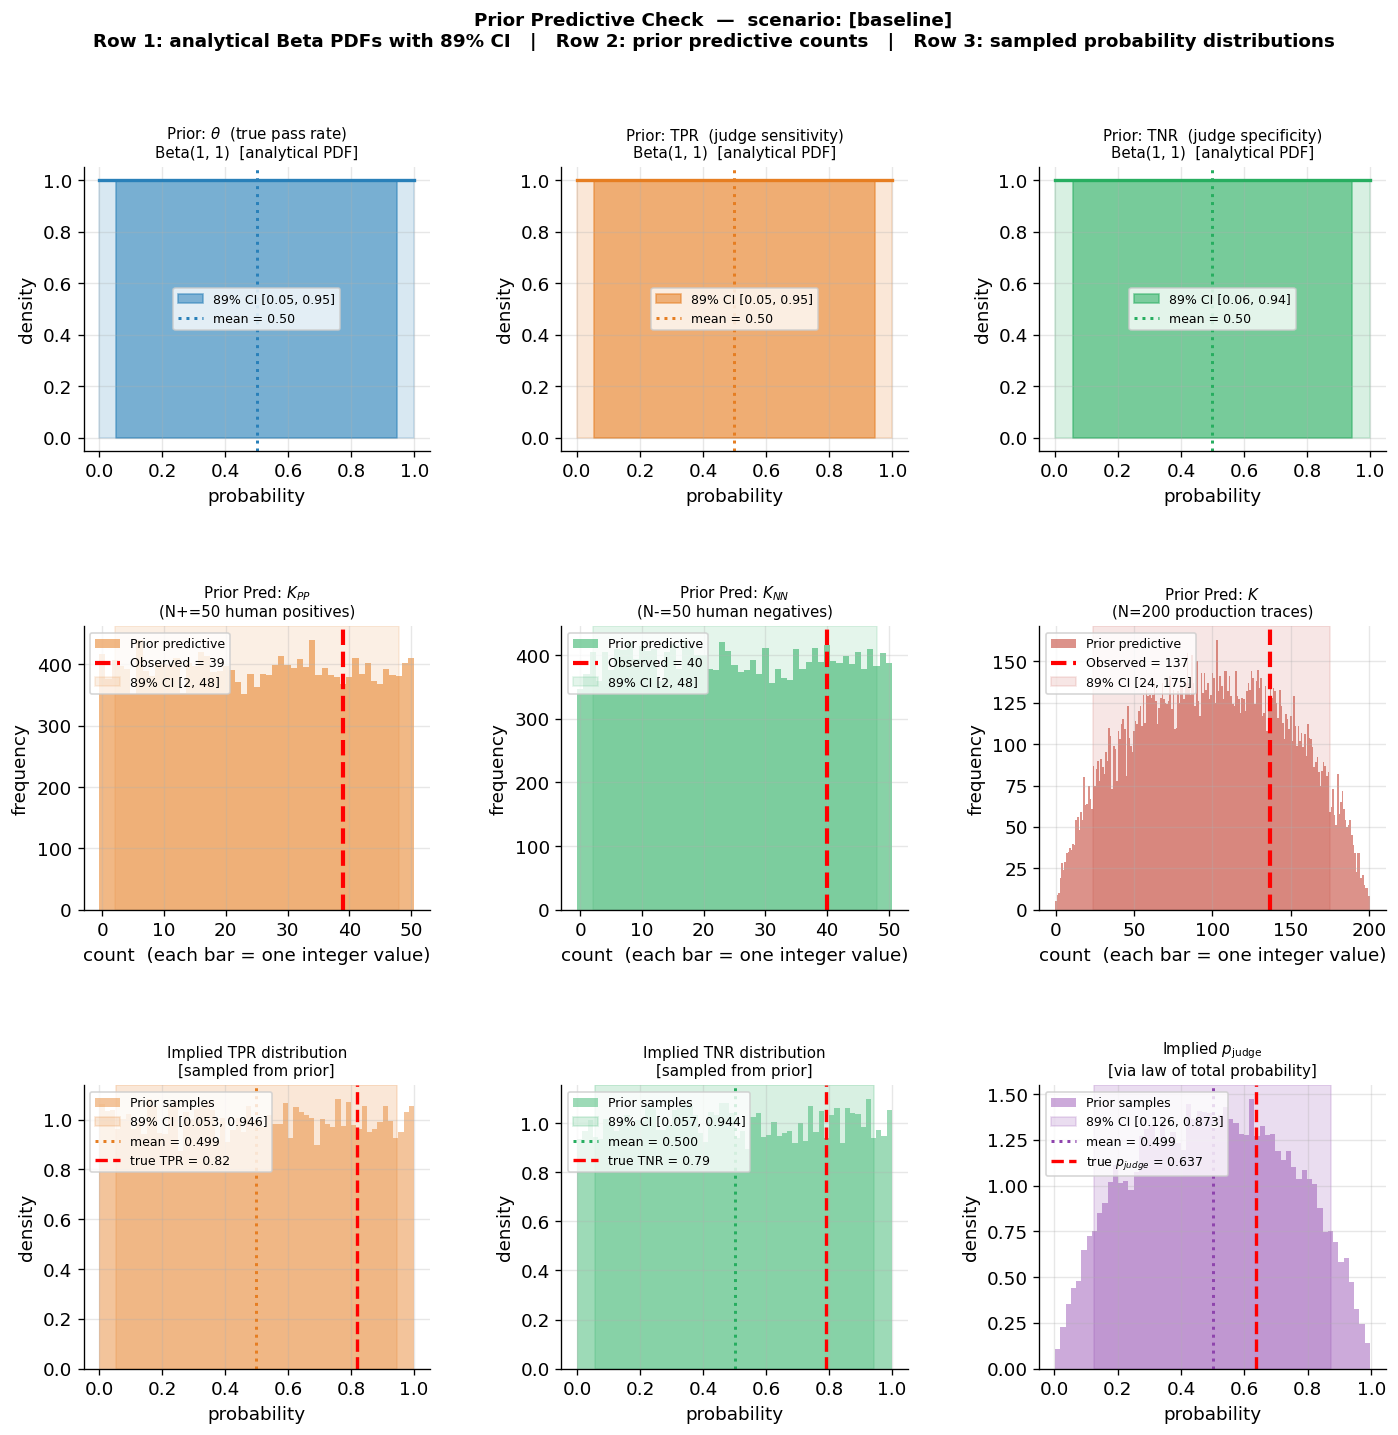

In [8]:
N_prior_samples = 20_000

# ── Sample from priors ───────────────────────────────────────────
theta_prior_s = rng.beta(cfg["theta_prior"][0], cfg["theta_prior"][1], N_prior_samples)
tpr_prior_s   = rng.beta(cfg["tpr_prior"][0],   cfg["tpr_prior"][1],   N_prior_samples)
tnr_prior_s   = rng.beta(cfg["tnr_prior"][0],   cfg["tnr_prior"][1],   N_prior_samples)

# ── Propagate through the model ──────────────────────────────────
p_judge_prior_s = theta_prior_s * tpr_prior_s + (1 - theta_prior_s) * (1 - tnr_prior_s)
K_prior_pred    = rng.binomial(cfg["N_prod"],    p_judge_prior_s)
K_pp_prior_pred = rng.binomial(cfg["n_val_pos"], tpr_prior_s)
K_nn_prior_pred = rng.binomial(cfg["n_val_neg"], tnr_prior_s)

# ── Helper: 89% CI ───────────────────────────────────────────────
def ci89(samples):
    return np.percentile(samples, [5.5, 94.5])

def obs_check(pred_samples, obs):
    lo, hi = ci89(pred_samples)
    flag = "✓ within" if lo <= obs <= hi else "✗ OUTSIDE"
    return lo, hi, flag

def int_bins(n):
    """Bins centred on integers 0..n — correct representation for discrete counts."""
    return np.arange(0, n + 2) - 0.5

theta_ci = ci89(theta_prior_s)
tpr_ci   = ci89(tpr_prior_s)
tnr_ci   = ci89(tnr_prior_s)
pj_ci    = ci89(p_judge_prior_s)

kpp_lo,  kpp_hi,  kpp_flag  = obs_check(K_pp_prior_pred, data["k_pp"])
knn_lo,  knn_hi,  knn_flag  = obs_check(K_nn_prior_pred, data["k_nn"])
kprd_lo, kprd_hi, kprd_flag = obs_check(K_prior_pred,    data["K_prod"])

# ── Print summary ─────────────────────────────────────────────────
print("PRIOR PREDICTIVE SUMMARY")
print("=" * 65)
print(f"  Priors:  θ~Beta{cfg['theta_prior']}  TPR~Beta{cfg['tpr_prior']}  TNR~Beta{cfg['tnr_prior']}")
print()
print("  Parameter priors — what does the prior believe?")
print(f"  {'Parameter':<10}  {'Mean':>6}  {'89% CI':<20}  Interpretation")
print("  " + "-" * 60)
print(f"  {'θ':<10}  {theta_prior_s.mean():>6.3f}  [{theta_ci[0]:.3f}, {theta_ci[1]:.3f}]          prior belief about true pass rate")
print(f"  {'TPR':<10}  {tpr_prior_s.mean():>6.3f}  [{tpr_ci[0]:.3f}, {tpr_ci[1]:.3f}]          prior belief about judge sensitivity")
print(f"  {'TNR':<10}  {tnr_prior_s.mean():>6.3f}  [{tnr_ci[0]:.3f}, {tnr_ci[1]:.3f}]          prior belief about judge specificity")
print(f"  {'p_judge':<10}  {p_judge_prior_s.mean():>6.3f}  [{pj_ci[0]:.3f}, {pj_ci[1]:.3f}]          implied observed judge pass rate")
print()
print("  Observable prior predictive checks")
print(f"  {'Observable':<12}  {'Observed':>8}  {'89% Prior CI':<18}  Check")
print("  " + "-" * 60)
print(f"  {'K_PP':<12}  {data['k_pp']:>8}  [{kpp_lo:5.0f}, {kpp_hi:5.0f}]           {kpp_flag} 89% CI")
print(f"  {'K_NN':<12}  {data['k_nn']:>8}  [{knn_lo:5.0f}, {knn_hi:5.0f}]           {knn_flag} 89% CI")
print(f"  {'K (prod)':<12}  {data['K_prod']:>8}  [{kprd_lo:5.0f}, {kprd_hi:5.0f}]           {kprd_flag} 89% CI")

# ── Colours ───────────────────────────────────────────────────────
COLORS = {"theta": "#2980B9", "tpr": "#E67E22", "tnr": "#27AE60",
          "pjudge": "#8E44AD", "K": "#C0392B"}
x = np.linspace(0.001, 0.999, 500)

fig = plt.figure(figsize=(14, 13))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.62, wspace=0.38)

# ── Row 1: analytical Beta PDFs with 89% CI shaded ───────────────
param_panels = [
    (cfg["theta_prior"], theta_prior_s, theta_ci,
     r"Prior: $\theta$  (true pass rate)",  COLORS["theta"]),
    (cfg["tpr_prior"],   tpr_prior_s,   tpr_ci,
     "Prior: TPR  (judge sensitivity)",    COLORS["tpr"]),
    (cfg["tnr_prior"],   tnr_prior_s,   tnr_ci,
     "Prior: TNR  (judge specificity)",    COLORS["tnr"]),
]
for col, (ab, samples, ci, title, color) in enumerate(param_panels):
    ax = fig.add_subplot(gs[0, col])
    pdf = beta_dist.pdf(x, ab[0], ab[1])
    ax.fill_between(x, pdf, alpha=0.18, color=color)
    ax.plot(x, pdf, color=color, lw=2)
    mask = (x >= ci[0]) & (x <= ci[1])
    ax.fill_between(x[mask], pdf[mask], alpha=0.55, color=color,
                    label=f"89% CI [{ci[0]:.2f}, {ci[1]:.2f}]")
    ax.axvline(samples.mean(), color=color, lw=1.8, linestyle=":",
               label=f"mean = {samples.mean():.2f}")
    ax.set_title(f"{title}\nBeta{ab}  [analytical PDF]", fontsize=9)
    ax.set_xlabel("probability")
    ax.set_ylabel("density")
    ax.legend(fontsize=7.5)

# ── Row 2: prior predictive counts — integer-aligned bins ─────────
obs_panels = [
    (K_pp_prior_pred, data["k_pp"],   kpp_lo,  kpp_hi,  cfg["n_val_pos"],
     f"Prior Pred: $K_{{PP}}$\n(N+={cfg['n_val_pos']} human positives)",
     COLORS["tpr"], "k_pp"),
    (K_nn_prior_pred, data["k_nn"],   knn_lo,  knn_hi,  cfg["n_val_neg"],
     f"Prior Pred: $K_{{NN}}$\n(N-={cfg['n_val_neg']} human negatives)",
     COLORS["tnr"], "k_nn"),
    (K_prior_pred,    data["K_prod"], kprd_lo, kprd_hi, cfg["N_prod"],
     f"Prior Pred: $K$\n(N={cfg['N_prod']} production traces)",
     COLORS["K"],   "K_prod"),
]
for col, (pred, obs, lo, hi, n_max, title, color, label) in enumerate(obs_panels):
    ax = fig.add_subplot(gs[1, col])
    ax.hist(pred, bins=int_bins(n_max), color=color, alpha=0.55,
            label="Prior predictive")
    ax.axvline(obs, color="red", lw=2.5, linestyle="--",
               label=f"Observed = {obs}")
    ax.axvspan(lo, hi, alpha=0.12, color=color,
               label=f"89% CI [{lo:.0f}, {hi:.0f}]")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("count  (each bar = one integer value)")
    ax.set_ylabel("frequency")
    ax.legend(fontsize=7.5)

# ── Row 3: sampled probability distributions — TPR, TNR, p_judge ─
prob_panels = [
    (tpr_prior_s,     tpr_ci,  cfg["true_tpr"],
     "Implied TPR distribution\n[sampled from prior]",
     COLORS["tpr"],    f"true TPR = {cfg['true_tpr']}"),
    (tnr_prior_s,     tnr_ci,  cfg["true_tnr"],
     "Implied TNR distribution\n[sampled from prior]",
     COLORS["tnr"],    f"true TNR = {cfg['true_tnr']}"),
    (p_judge_prior_s, pj_ci,   p_judge_true,
     r"Implied $p_{\mathrm{judge}}$" + "\n[via law of total probability]",
     COLORS["pjudge"], f"true $p_{{judge}}$ = {p_judge_true:.3f}"),
]
for col, (samples, ci, truth, title, color, truth_label) in enumerate(prob_panels):
    ax = fig.add_subplot(gs[2, col])
    ax.hist(samples, bins=60, color=color, alpha=0.45, density=True,
            label="Prior samples")
    ax.axvspan(ci[0], ci[1], alpha=0.18, color=color,
               label=f"89% CI [{ci[0]:.3f}, {ci[1]:.3f}]")
    ax.axvline(samples.mean(), color=color, lw=1.8, linestyle=":",
               label=f"mean = {samples.mean():.3f}")
    ax.axvline(truth, color="red", lw=2, linestyle="--", label=truth_label)
    ax.set_xlabel("probability")
    ax.set_ylabel("density")
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7.5)

fig.suptitle(
    f"Prior Predictive Check  —  scenario: [{ACTIVE_SCENARIO}]\n"
    "Row 1: analytical Beta PDFs with 89% CI   |   "
    "Row 2: prior predictive counts   |   "
    "Row 3: sampled probability distributions",
    fontsize=11, fontweight="bold"
)
plt.show()

## Part 3: Grid Approximation — The Glass Box

Grid approximation is the most transparent way to compute a posterior. It is slow and doesn't scale beyond a few parameters — but it makes every step of Bayesian inference **visible and inspectable**. No black boxes.

### The Idea

Discretise each parameter into a grid of evenly spaced values. Evaluate the posterior at every combination. Normalise so the values sum to 1.

For our model with 3 parameters, this means a **3D grid**: one axis for $\theta$, one for TPR, one for TNR. Each cell of the grid holds the (unnormalised) posterior probability at that combination.

### The Four Steps

**Step 1 — Log prior** at every grid point:
$$\log P(\theta, \text{TPR}, \text{TNR}) = \log P(\theta) + \log P(\text{TPR}) + \log P(\text{TNR})$$

**Step 2 — Log likelihood** from validation set:
$$\log P(K_{PP} \mid N_+, \text{TPR}) + \log P(K_{NN} \mid N_-, \text{TNR})$$

**Step 3 — Log likelihood** from production:
$$\log P(K \mid N,\; \theta \cdot \text{TPR} + (1-\theta)(1-\text{TNR}))$$

**Step 4 — Sum and normalise** (in log space for numerical stability):
$$\log \text{posterior} = \text{Step 1} + \text{Step 2} + \text{Step 3} - \log Z$$

where $\log Z = \text{logsumexp}(\text{all grid values})$ is the normalising constant.

### Why Log Space?

Individual likelihoods can be astronomically small numbers (e.g. $10^{-300}$). Multiplying them in linear space causes **underflow** — the computer rounds to zero and you lose everything. Working in log space turns multiplications into additions, which are numerically stable.

### Marginalisation = Array Summation

This is the payoff. The 3D posterior array has shape `(G, G, G)` where G is the grid size. To get the marginal posterior of $\theta$:

```python
marginal_theta = posterior_3d.sum(axis=(1, 2))   # sum over TPR and TNR dimensions
```

That single line **is** the double integral $\iint P(\theta, \text{TPR}, \text{TNR} \mid \text{data})\; d\text{TPR}\; d\text{TNR}$. No approximation beyond the grid resolution.

### Identifiability Check

Before trusting any results, recall: the model is only identified when $\text{TPR} + \text{TNR} > 1$ (judge is better than chance). We will check this on the posterior.

In [9]:
GRID_SIZE = 50   # 50³ = 125,000 parameter combinations — fast and accurate enough
EPS       = 1e-9  # keep away from 0 and 1 to avoid log(0)

# ── 1D parameter grids — shape (GRID_SIZE,) = (50,) ─────────────
# These are evenly spaced candidate values for each parameter.
# Think of them as the "ruler marks" along each axis of the 3D space.
theta_grid = np.linspace(EPS, 1 - EPS, GRID_SIZE)  # (50,)  candidate true pass rates
tpr_grid   = np.linspace(EPS, 1 - EPS, GRID_SIZE)  # (50,)  candidate TPR values
tnr_grid   = np.linspace(EPS, 1 - EPS, GRID_SIZE)  # (50,)  candidate TNR values

# ── Expand 1D grids into a 3D parameter space ────────────────────
# meshgrid with indexing='ij':
#   axis 0 → θ   (GRID_SIZE values, repeated across TPR and TNR)
#   axis 1 → TPR (GRID_SIZE values, repeated across θ   and TNR)
#   axis 2 → TNR (GRID_SIZE values, repeated across θ   and TPR)
# Every cell [i, j, k] represents one (θ, TPR, TNR) combination.
THETA, TPR, TNR = np.meshgrid(theta_grid, tpr_grid, tnr_grid, indexing='ij')
# THETA, TPR, TNR each have shape (50, 50, 50) = (GRID_SIZE, GRID_SIZE, GRID_SIZE)

# ================================================================
# STEP 1 — Log Prior at every grid point
# shape: (50, 50, 50)
# Adding log PDFs = multiplying the independent priors
# ================================================================
log_prior = (
    beta_dist.logpdf(THETA, cfg["theta_prior"][0], cfg["theta_prior"][1]) +
    beta_dist.logpdf(TPR,   cfg["tpr_prior"][0],   cfg["tpr_prior"][1])   +
    beta_dist.logpdf(TNR,   cfg["tnr_prior"][0],   cfg["tnr_prior"][1])
)
# log_prior.shape → (50, 50, 50)

# ================================================================
# STEP 2 — Log Likelihood from Validation Set
# shape: (50, 50, 50)
# K_PP only depends on TPR; K_NN only depends on TNR.
# They are conditionally independent → add log-likelihoods.
# ================================================================
log_lik_val = (
    binom.logpmf(data["k_pp"], cfg["n_val_pos"], TPR) +   # K_PP ~ Binom(N+, TPR)
    binom.logpmf(data["k_nn"], cfg["n_val_neg"], TNR)      # K_NN ~ Binom(N-, TNR)
)
# log_lik_val.shape → (50, 50, 50)

# ================================================================
# STEP 3 — Log Likelihood from Production
# shape: (50, 50, 50)
# p_judge varies at every grid point — it is a 3D array.
# ================================================================
p_judge_grid = THETA * TPR + (1 - THETA) * (1 - TNR)      # law of total probability
log_lik_prod = binom.logpmf(data["K_prod"], cfg["N_prod"], p_judge_grid)
# log_lik_prod.shape → (50, 50, 50)

# ================================================================
# STEP 4 — Joint Log Posterior & Normalise
# shape: (50, 50, 50)
#
# log P(θ,TPR,TNR|data) = log P(K|p_judge) + log P(K_PP|TPR)
#                        + log P(K_NN|TNR)  + log P(θ) + log P(TPR) + log P(TNR)
#                        - log Z            ← normalising constant
# ================================================================
log_joint = log_prior + log_lik_val + log_lik_prod
# log_joint is unnormalised — values are large negative numbers

# Normalise in log space.
# In linear space: posterior[i] = unnorm[i] / sum(unnorm)
# In log space:  log_posterior[i] = log_unnorm[i] - log(sum(exp(log_unnorm)))
#                                  = log_unnorm[i] - logsumexp(log_unnorm)
#
# .ravel() flattens (50,50,50) → (125000,) so we sum over ALL grid points.
# logsumexp computes log(Σ exp(x)) stably — no underflow to zero.
# After this step: exp(log_joint).sum() == 1.0  ← proper probability distribution
log_joint -= logsumexp(log_joint.ravel())
posterior_3d = np.exp(log_joint)    # shape (50, 50, 50), sums to 1.0

# ================================================================
# MARGINALISATION — sum over nuisance dimensions
# ================================================================
# Each line IS the discrete approximation of a double integral.
# Summing over axis (1,2) = integrating out TPR and TNR → marginal over θ only.
marginal_theta = posterior_3d.sum(axis=(1, 2))   # (50,)  ∫∫ ... dTPR dTNR
marginal_tpr   = posterior_3d.sum(axis=(0, 2))   # (50,)  ∫∫ ... dθ   dTNR
marginal_tnr   = posterior_3d.sum(axis=(0, 1))   # (50,)  ∫∫ ... dθ   dTPR

# Posterior mean of p_judge (weighted average over full joint)
p_judge_marginal = (p_judge_grid * posterior_3d).sum()

# ================================================================
# POSTERIOR STATISTICS
# ================================================================
def grid_stats(grid_vals, marginal):
    """Posterior mean and 89% credible interval from a 1D marginal."""
    mean = np.sum(grid_vals * marginal)
    cdf  = np.cumsum(marginal)
    lo   = grid_vals[np.searchsorted(cdf, 0.055)]
    hi   = grid_vals[np.searchsorted(cdf, 0.945)]
    return mean, lo, hi

theta_mean, theta_lo, theta_hi = grid_stats(theta_grid, marginal_theta)
tpr_mean,   tpr_lo,   tpr_hi   = grid_stats(tpr_grid,   marginal_tpr)
tnr_mean,   tnr_lo,   tnr_hi   = grid_stats(tnr_grid,   marginal_tnr)

tpr_tnr_sum = tpr_mean + tnr_mean
identified  = "✓ identified" if tpr_tnr_sum > 1 else "✗ NOT identified (TPR + TNR ≤ 1)"

print("GRID APPROXIMATION — POSTERIOR RESULTS")
print("=" * 65)
print(f"  Grid size : {GRID_SIZE}³ = {GRID_SIZE**3:,} parameter combinations")
print(f"  Scenario  : [{ACTIVE_SCENARIO}]")
print()
print(f"  {'Parameter':<10}  {'Post. Mean':>10}  {'89% Credible Interval':<24}  Truth")
print("  " + "-" * 62)
print(f"  {'θ':<10}  {theta_mean:>10.3f}  [{theta_lo:.3f}, {theta_hi:.3f}]                  {cfg['true_theta']}")
print(f"  {'TPR':<10}  {tpr_mean:>10.3f}  [{tpr_lo:.3f}, {tpr_hi:.3f}]                  {cfg['true_tpr']}")
print(f"  {'TNR':<10}  {tnr_mean:>10.3f}  [{tnr_lo:.3f}, {tnr_hi:.3f}]                  {cfg['true_tnr']}")
print()
print(f"  Implied p_judge (posterior mean) : {p_judge_marginal:.3f}   (true: {p_judge_true:.3f})")
print(f"  Naive estimate K/N               : {data['K_prod']/cfg['N_prod']:.3f}   (biased)")
print(f"  Identifiability  TPR + TNR       : {tpr_tnr_sum:.3f}   {identified}")

GRID APPROXIMATION — POSTERIOR RESULTS
  Grid size : 50³ = 125,000 parameter combinations
  Scenario  : [baseline]

  Parameter   Post. Mean  89% Credible Interval     Truth
  --------------------------------------------------------------
  θ                0.835  [0.694, 0.980]                  0.7
  TPR              0.775  [0.694, 0.857]                  0.82
  TNR              0.783  [0.694, 0.878]                  0.79

  Implied p_judge (posterior mean) : 0.680   (true: 0.637)
  Naive estimate K/N               : 0.685   (biased)
  Identifiability  TPR + TNR       : 1.557   ✓ identified


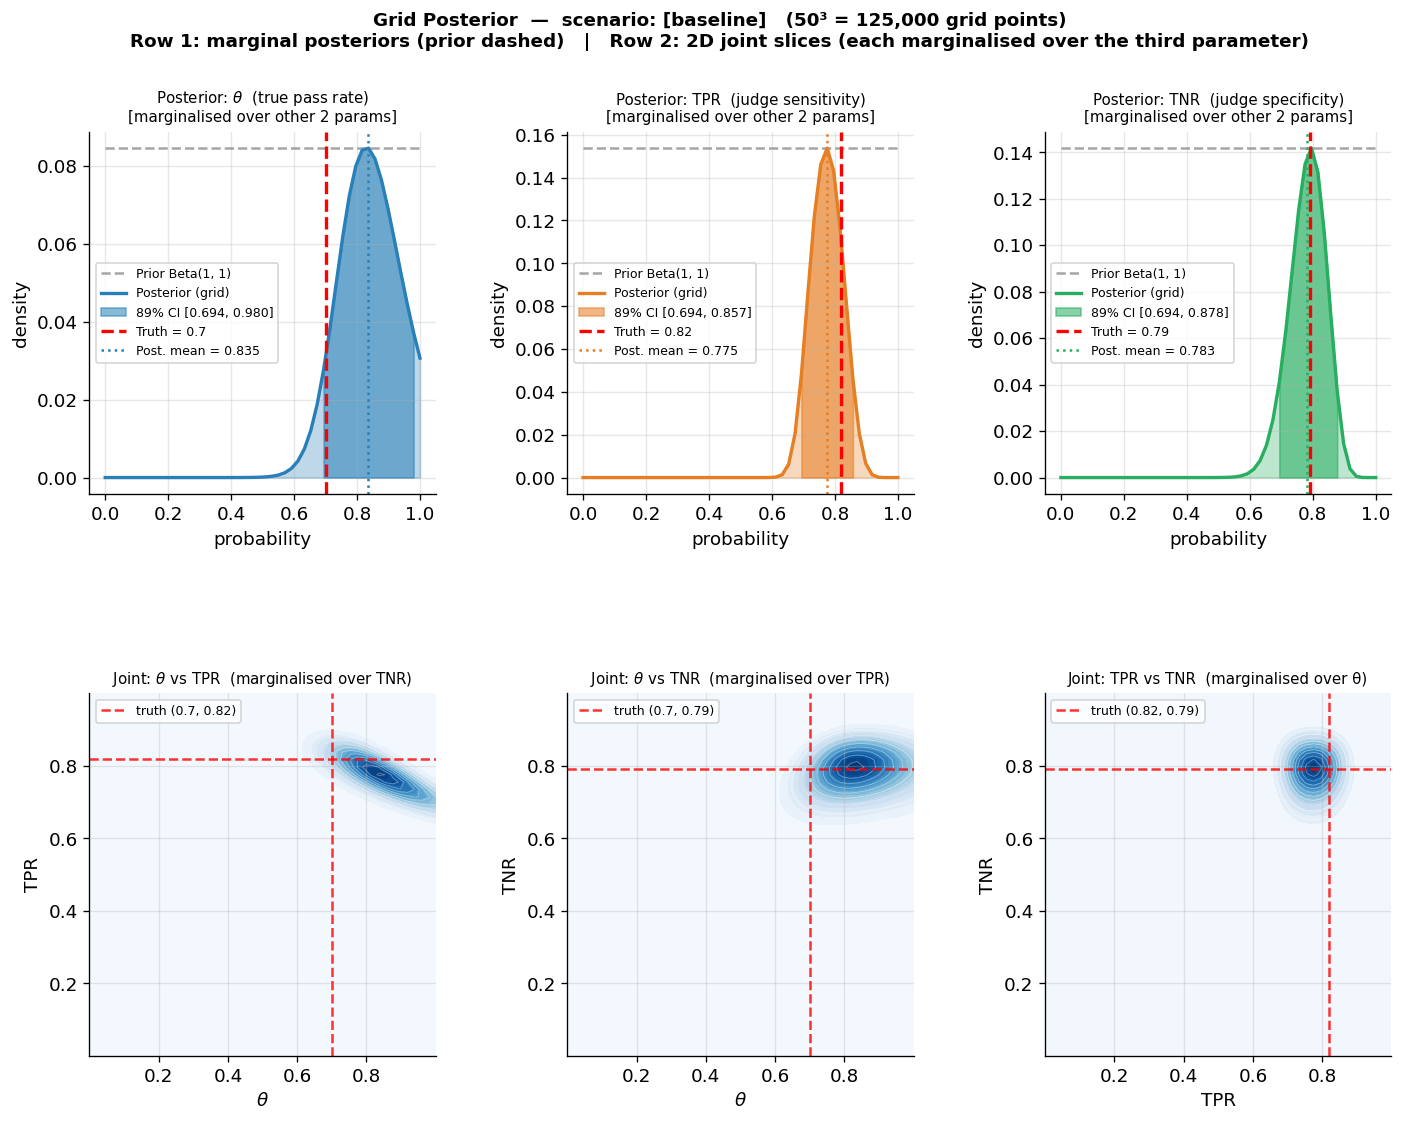

In [10]:
x = np.linspace(EPS, 1 - EPS, 500)

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.38)

grid_panels = [
    (theta_grid, marginal_theta, theta_mean, theta_lo, theta_hi,
     cfg["theta_prior"], cfg["true_theta"],
     r"Posterior: $\theta$  (true pass rate)", COLORS["theta"]),
    (tpr_grid,   marginal_tpr,   tpr_mean,   tpr_lo,   tpr_hi,
     cfg["tpr_prior"],   cfg["true_tpr"],
     "Posterior: TPR  (judge sensitivity)",   COLORS["tpr"]),
    (tnr_grid,   marginal_tnr,   tnr_mean,   tnr_lo,   tnr_hi,
     cfg["tnr_prior"],   cfg["true_tnr"],
     "Posterior: TNR  (judge specificity)",   COLORS["tnr"]),
]

for col, (grid, marg, mean, lo, hi, prior_ab, truth, title, color) in enumerate(grid_panels):

    # ── Row 1: prior vs posterior overlay ────────────────────────
    ax = fig.add_subplot(gs[0, col])

    # Prior (analytical, normalised to match posterior scale)
    prior_pdf = beta_dist.pdf(x, prior_ab[0], prior_ab[1])
    prior_pdf_norm = prior_pdf / (prior_pdf.sum() * (x[1] - x[0]))
    scale = marg.max() / prior_pdf_norm.max() if prior_pdf_norm.max() > 0 else 1
    ax.plot(x, prior_pdf_norm * scale, color="gray", lw=1.5,
            linestyle="--", alpha=0.7, label=f"Prior Beta{prior_ab}")

    # Posterior
    ax.fill_between(grid, marg, alpha=0.30, color=color)
    ax.plot(grid, marg, color=color, lw=2, label="Posterior (grid)")

    # 89% CI shaded
    mask = (grid >= lo) & (grid <= hi)
    ax.fill_between(grid[mask], marg[mask], alpha=0.55, color=color,
                    label=f"89% CI [{lo:.3f}, {hi:.3f}]")

    # Truth and mean
    ax.axvline(truth, color="red", lw=2, linestyle="--",
               label=f"Truth = {truth}")
    ax.axvline(mean, color=color, lw=1.5, linestyle=":",
               label=f"Post. mean = {mean:.3f}")

    ax.set_title(f"{title}\n[marginalised over other 2 params]", fontsize=9)
    ax.set_xlabel("probability")
    ax.set_ylabel("density")
    ax.legend(fontsize=7.5)

# ── Row 2: 2D joint slices (θ vs TPR, θ vs TNR, TPR vs TNR) ─────
joint_panels = [
    (posterior_3d.sum(axis=2), theta_grid, tpr_grid,
     r"Joint: $\theta$ vs TPR  (marginalised over TNR)",
     r"$\theta$", "TPR"),
    (posterior_3d.sum(axis=1), theta_grid, tnr_grid,
     r"Joint: $\theta$ vs TNR  (marginalised over TPR)",
     r"$\theta$", "TNR"),
    (posterior_3d.sum(axis=0), tpr_grid,   tnr_grid,
     "Joint: TPR vs TNR  (marginalised over θ)",
     "TPR", "TNR"),
]
for col, (joint_2d, xg, yg, title, xlabel, ylabel) in enumerate(joint_panels):
    ax = fig.add_subplot(gs[1, col])
    ax.contourf(xg, yg, joint_2d.T, levels=20, cmap="Blues")
    ax.contour( xg, yg, joint_2d.T, levels=10, colors="white",
                linewidths=0.5, alpha=0.4)
    # True value crosshairs
    true_x = cfg["true_theta"] if xlabel == r"$\theta$" else (cfg["true_tpr"] if xlabel == "TPR" else cfg["true_tnr"])
    true_y = cfg["true_tpr"]   if ylabel == "TPR"        else cfg["true_tnr"]
    ax.axvline(true_x, color="red", lw=1.5, linestyle="--", alpha=0.8)
    ax.axhline(true_y, color="red", lw=1.5, linestyle="--", alpha=0.8,
               label=f"truth ({true_x}, {true_y})")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7.5)

fig.suptitle(
    f"Grid Posterior  —  scenario: [{ACTIVE_SCENARIO}]   "
    f"({GRID_SIZE}³ = {GRID_SIZE**3:,} grid points)\n"
    "Row 1: marginal posteriors (prior dashed)   |   "
    "Row 2: 2D joint slices (each marginalised over the third parameter)",
    fontsize=11, fontweight="bold"
)
plt.show()

## Part 4: MCMC with PyMC — The Fast Lane

Grid approximation is beautiful but it has a fatal flaw: it scales as $G^P$ where $G$ is the grid size and $P$ is the number of parameters. With 3 parameters and G=50 that's 125,000 points. Add a 4th parameter and it becomes 6.25 million. A 10th parameter is computationally impossible.

**MCMC (Markov Chain Monte Carlo)** sidesteps this entirely. Instead of evaluating the posterior everywhere, it **draws samples** from the posterior by walking through parameter space — spending more time where the posterior is high, less where it is low. The histogram of samples IS the posterior.

### How NUTS Works (Plain English)

PyMC uses the **No-U-Turn Sampler (NUTS)**, a variant of Hamiltonian Monte Carlo:

1. Imagine a ball rolling on a surface whose height is the **negative log posterior** (a landscape of hills and valleys)
2. The ball follows physics — it rolls downhill (toward high probability) but also has momentum carrying it across ridges
3. NUTS automatically decides how long to let the ball roll before taking a sample — no manual tuning needed
4. The samples it collects follow the posterior distribution exactly (in the limit)

The key insight: NUTS only needs to **evaluate the gradient** of the log posterior, not its value everywhere. This is why it scales to hundreds of parameters.

### What to Check After Sampling

| Diagnostic | Good value | Meaning |
|------------|------------|---------|
| `r_hat` | ≈ 1.00 | Chains mixed well — all exploring the same posterior |
| `ess_bulk` | > 400 | Enough effective samples for reliable estimates |
| Trace plot | Hairy caterpillar | Chain is mixing, not stuck |

### The Model Is Identical

The PyMC model below is a direct translation of the mathematical model — same priors, same likelihoods, same structure. The only difference is *how* the posterior is computed: grid sums vs MCMC samples.

In [11]:

import pymc as pm
import arviz as az

# ── Build the PyMC model ───────────────────────────────────────────────────────
# The model mirrors the mathematical generative model exactly.
# PyMC translates the notation almost one-to-one.

with pm.Model() as judge_model:

    # ── Priors ────────────────────────────────────────────────────────────────
    # Each latent parameter gets a Beta prior from the active scenario config.
    theta = pm.Beta("theta", alpha=cfg["theta_prior"][0], beta=cfg["theta_prior"][1])
    tpr   = pm.Beta("tpr",   alpha=cfg["tpr_prior"][0],   beta=cfg["tpr_prior"][1])
    tnr   = pm.Beta("tnr",   alpha=cfg["tnr_prior"][0],   beta=cfg["tnr_prior"][1])

    # ── Deterministic bridge ──────────────────────────────────────────────────
    # p_judge = θ·TPR + (1-θ)·(1-TNR)  ← Law of Total Probability
    # Declared as pm.Deterministic so ArviZ tracks it in the trace.
    p_judge = pm.Deterministic("p_judge", theta * tpr + (1 - theta) * (1 - tnr))

    # ── Likelihoods ───────────────────────────────────────────────────────────
    # Observed nodes: PyMC pins these to the data and uses them to update beliefs.
    _kpp   = pm.Binomial("k_pp",   n=cfg["n_val_pos"], p=tpr,     observed=data["k_pp"])
    _knn   = pm.Binomial("k_nn",   n=cfg["n_val_neg"], p=tnr,     observed=data["k_nn"])
    _kprod = pm.Binomial("K_prod", n=cfg["N_prod"],    p=p_judge, observed=data["K_prod"])

    # ── Sample ────────────────────────────────────────────────────────────────
    # NUTS sampler: 2000 draws per chain, 1000 tuning steps, 4 chains (default).
    # target_accept=0.9 → smaller step size, better for curved geometry.
    idata = pm.sample(
        draws=2000,
        tune=1000,
        target_accept=0.9,
        random_seed=42,
        progressbar=True,
    )

print("\nSampling complete.")
print(f"Chains: {idata.posterior.sizes['chain']}   "
      f"Draws per chain: {idata.posterior.sizes['draw']}")


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, tpr, tnr]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 12 seconds.



Sampling complete.
Chains: 4   Draws per chain: 2000


=== ArviZ summary (89% HDI) ===
        mean     sd  hdi_5.5%  hdi_94.5%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
theta  0.833  0.086     0.698      0.971      0.002    0.001    2532.0    2121.0    1.0
tpr    0.776  0.048     0.702      0.857      0.001    0.001    2963.0    3314.0    1.0
tnr    0.784  0.057     0.696      0.876      0.001    0.001    4195.0    3697.0    1.0

=== Convergence check ===
  theta  r_hat=1.0000 ✓   ess_bulk=2532 ✓
  tpr    r_hat=1.0000 ✓   ess_bulk=2963 ✓
  tnr    r_hat=1.0000 ✓   ess_bulk=4195 ✓

=== 89% Credible Intervals ===

  THETA  [0.692, 0.966]   mean=0.833   truth=0.7 ✓ inside
         → "Given the data, there is an 89% probability the true pass rate
           lies between 0.692 and 0.966."

  TPR    [0.698, 0.854]   mean=0.776   truth=0.82 ✓ inside
         → "Given the data, there is an 89% probability the judge sensitivity (TPR)
           lies between 0.698 and 0.854."

  TNR    [0.687, 0.868]   mean=0.784   truth=0.79 ✓ inside
         

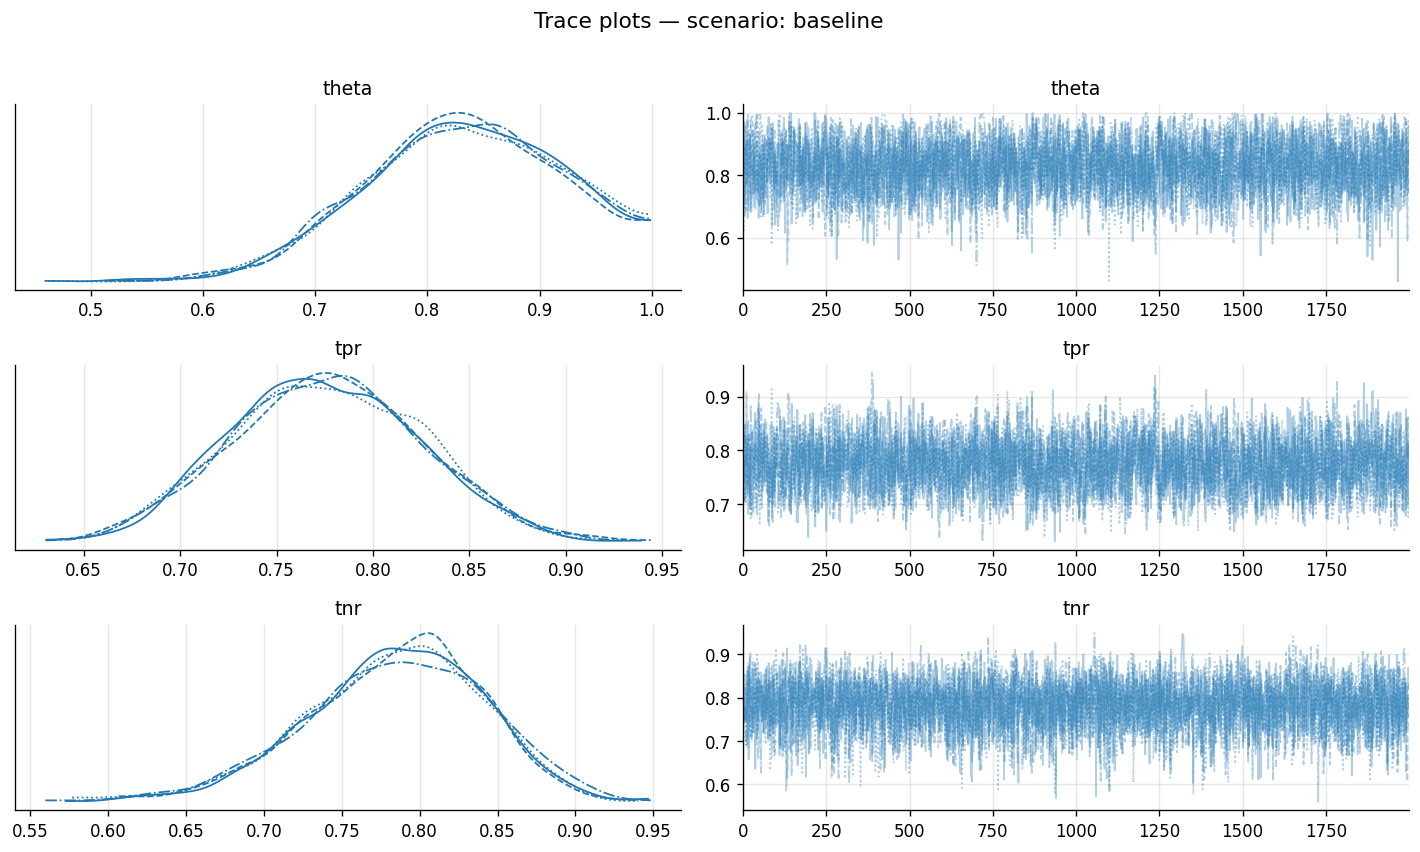

In [12]:

# ── Convergence diagnostics ────────────────────────────────────────────────────
# Rule of thumb: r_hat < 1.01 and ess_bulk > 400 = healthy chain.

summary = az.summary(idata, var_names=["theta", "tpr", "tnr"], hdi_prob=0.89)
print("=== ArviZ summary (89% HDI) ===")
print(summary.to_string())

print("\n=== Convergence check ===")
for var in ["theta", "tpr", "tnr"]:
    rhat = float(summary.loc[var, "r_hat"])
    ess  = float(summary.loc[var, "ess_bulk"])
    rhat_ok = "✓" if rhat < 1.01 else "✗ HIGH"
    ess_ok  = "✓" if ess  > 400  else "✗ LOW"
    print(f"  {var:5s}  r_hat={rhat:.4f} {rhat_ok}   ess_bulk={ess:.0f} {ess_ok}")

# ── 89% Credible Intervals — plain English ────────────────────────────────────
param_labels = {
    "theta": ("true pass rate",      cfg["true_theta"]),
    "tpr":   ("judge sensitivity (TPR)", cfg["true_tpr"]),
    "tnr":   ("judge specificity (TNR)", cfg["true_tnr"]),
}

print("\n=== 89% Credible Intervals ===\n")
for var, (label, truth) in param_labels.items():
    samples = idata.posterior[var].values.ravel()
    lo, hi  = np.percentile(samples, [5.5, 94.5])
    mean    = samples.mean()
    inside  = "✓ inside" if lo <= truth <= hi else "✗ OUTSIDE"
    print(f"  {var.upper():<5s}  [{lo:.3f}, {hi:.3f}]   mean={mean:.3f}   truth={truth} {inside}")
    print(f"         → \"Given the data, there is an 89% probability the {label}")
    print(f"           lies between {lo:.3f} and {hi:.3f}.\"")
    print()

# ── Trace plots ────────────────────────────────────────────────────────────────
axes = az.plot_trace(
    idata,
    var_names=["theta", "tpr", "tnr"],
    figsize=(12, 7),
    combined=False,
)
plt.suptitle(f"Trace plots — scenario: {ACTIVE_SCENARIO}", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


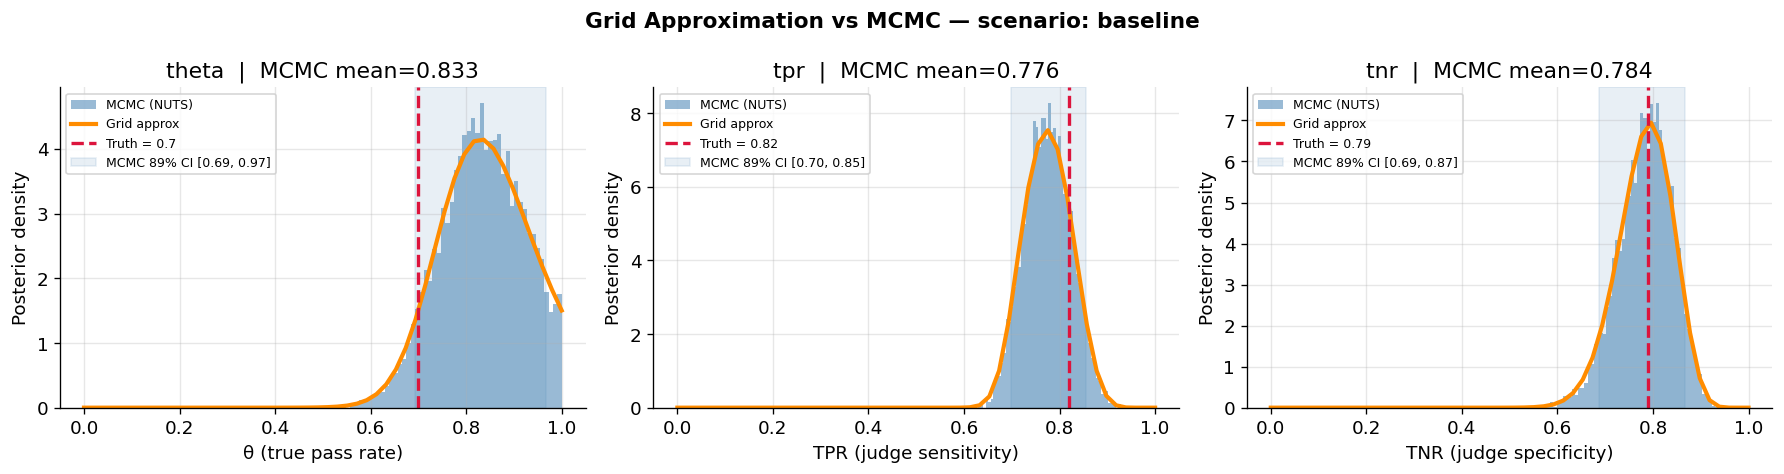


           Grid mean   MCMC mean     Truth    Agree?
--------------------------------------------------------
  theta      0.8345      0.8325     0.700         ✓
  tpr        0.7747      0.7757     0.820         ✓
  tnr        0.7826      0.7840     0.790         ✓


In [13]:

# ── Grid vs MCMC overlay ───────────────────────────────────────────────────────
# Both methods are solving the same problem.  They should agree.
# Grid: smooth curve from explicit 3D summation.
# MCMC: histogram from 8,000 posterior samples (4 chains × 2,000 draws).

params = [
    ("theta", theta_grid,  marginal_theta,  "θ (true pass rate)",    cfg["true_theta"]),
    ("tpr",   tpr_grid,    marginal_tpr,    "TPR (judge sensitivity)", cfg["true_tpr"]),
    ("tnr",   tnr_grid,    marginal_tnr,    "TNR (judge specificity)", cfg["true_tnr"]),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    f"Grid Approximation vs MCMC — scenario: {ACTIVE_SCENARIO}",
    fontsize=13, fontweight="bold"
)

for ax, (var, grid, marginal, label, truth) in zip(axes, params):
    # MCMC posterior (histogram, normalised to density)
    mcmc_samples = idata.posterior[var].values.ravel()  # all chains, all draws
    ax.hist(
        mcmc_samples, bins=60, density=True,
        color="steelblue", alpha=0.55, label="MCMC (NUTS)"
    )

    # Grid posterior (curve)
    # marginal is already a PMF over the grid; convert to density by dividing by bin width
    bin_width = grid[1] - grid[0]
    ax.plot(grid, marginal / bin_width, color="darkorange", lw=2.5, label="Grid approx")

    # Truth
    ax.axvline(truth, color="crimson", lw=2, ls="--", label=f"Truth = {truth}")

    # 89% CI from MCMC
    lo, hi = np.percentile(mcmc_samples, [5.5, 94.5])
    ax.axvspan(lo, hi, alpha=0.12, color="steelblue", label=f"MCMC 89% CI [{lo:.2f}, {hi:.2f}]")

    ax.set_xlabel(label)
    ax.set_ylabel("Posterior density")
    ax.legend(fontsize=7.5, loc="upper left")
    ax.set_title(f"{var}  |  MCMC mean={mcmc_samples.mean():.3f}")

plt.tight_layout()
plt.show()

# ── Numerical comparison ───────────────────────────────────────────────────────
print(f"\n{'':8s}  {'Grid mean':>10s}  {'MCMC mean':>10s}  {'Truth':>8s}  {'Agree?':>8s}")
print("-" * 56)
for var, grid, marginal, label, truth in params:
    grid_mean = float(np.sum(grid * marginal))
    mcmc_mean = float(idata.posterior[var].values.mean())
    agree = "✓" if abs(grid_mean - mcmc_mean) < 0.01 else "~"
    print(f"  {var:5s}  {grid_mean:>10.4f}  {mcmc_mean:>10.4f}  {truth:>8.3f}  {agree:>8s}")



## Part 5: Posterior Predictive Check

The posterior predictive check answers a simple but important question:

> **If we re-ran the experiment using the fitted model, would we get data that looks like what we actually observed?**

Formally, the **posterior predictive distribution** is:

$$p(\tilde{y} \mid y) = \int p(\tilde{y} \mid \theta)\; p(\theta \mid y)\; d\theta$$

In practice with MCMC:
1. For each posterior sample $(\theta^s, \text{TPR}^s, \text{TNR}^s)$, compute $p_\text{judge}^s$
2. Draw a new count $\tilde{K} \sim \text{Binomial}(N, p_\text{judge}^s)$
3. Repeat for all $S$ samples → a distribution of *plausible* counts

If the observed $K$ sits comfortably inside this distribution, the model is consistent with the data.
If the observed $K$ is in the tail, the model is **misspecified** — something is wrong.

This is a sanity check before trusting any conclusions — including the hypothesis experiments ahead.


Sampling: [K_prod, k_nn, k_pp]


=== Posterior Predictive Check ===

  K_prod    observed= 137   89% CI=[121, 150]   percentile=51.0%   ✓ plausible
           → "If we repeated this experiment, we'd plausibly see 137 — the
              model is consistent with the observed data."

  k_pp      observed=  39   89% CI=[32, 45]   percentile=44.9%   ✓ plausible
           → "If we repeated this experiment, we'd plausibly see 39 — the
              model is consistent with the observed data."

  k_nn      observed=  40   89% CI=[32, 45]   percentile=50.1%   ✓ plausible
           → "If we repeated this experiment, we'd plausibly see 40 — the
              model is consistent with the observed data."



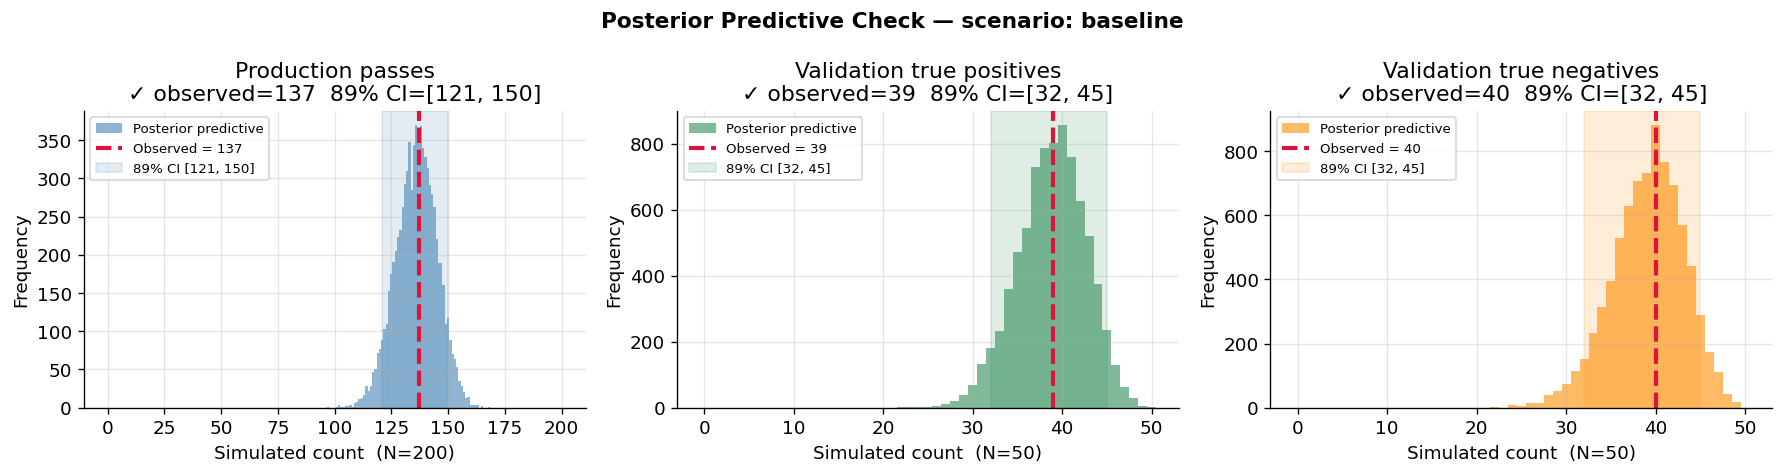

In [14]:

# ── Sample posterior predictive ────────────────────────────────────────────────
# PyMC replays the generative model forward using posterior samples.
# Each draw: (θ, TPR, TNR) from posterior → compute p_judge → draw new K counts.

with judge_model:
    ppc = pm.sample_posterior_predictive(idata, random_seed=42, progressbar=False)

# Flatten across chains and draws → shape (8000,)
pp_kprod = ppc.posterior_predictive["K_prod"].values.ravel()
pp_kpp   = ppc.posterior_predictive["k_pp"].values.ravel()
pp_knn   = ppc.posterior_predictive["k_nn"].values.ravel()

# ── Plot ───────────────────────────────────────────────────────────────────────
checks = [
    ("K_prod", pp_kprod, data["K_prod"], cfg["N_prod"],    "Production passes",         "steelblue"),
    ("k_pp",   pp_kpp,   data["k_pp"],   cfg["n_val_pos"], "Validation true positives", "seagreen"),
    ("k_nn",   pp_knn,   data["k_nn"],   cfg["n_val_neg"], "Validation true negatives", "darkorange"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"Posterior Predictive Check — scenario: {ACTIVE_SCENARIO}",
             fontsize=13, fontweight="bold")

print("=== Posterior Predictive Check ===\n")

for ax, (key, pp, observed, n_total, label, color) in zip(axes, checks):
    lo, hi = np.percentile(pp, [5.5, 94.5])
    inside = lo <= observed <= hi
    pct    = (pp < observed).mean() * 100

    ax.hist(pp, bins=int_bins(n_total), density=False, color=color, alpha=0.6,
            label="Posterior predictive")
    ax.axvline(observed, color="crimson", lw=2.5, ls="--", label=f"Observed = {observed}")
    ax.axvspan(lo, hi, alpha=0.15, color=color, label=f"89% CI [{lo:.0f}, {hi:.0f}]")

    marker = "✓" if inside else "✗"
    ax.set_xlabel(f"Simulated count  (N={n_total})")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{label}\n{marker} observed={observed}  89% CI=[{lo:.0f}, {hi:.0f}]")
    ax.legend(fontsize=8)

    # Plain-English summary
    status = "plausible" if inside else "SURPRISING — tail event"
    print(f"  {key:8s}  observed={observed:4d}   89% CI=[{lo:.0f}, {hi:.0f}]   "
          f"percentile={pct:.1f}%   {marker} {status}")
    if inside:
        print(f"           → \"If we repeated this experiment, we'd plausibly see {observed} — the")
        print(f"              model is consistent with the observed data.\"")
    else:
        print(f"           → \"The observed {observed} is in the tail of what the model predicts.")
        print(f"              This suggests model misspecification.\"")
    print()

plt.tight_layout()
plt.show()



## Part 6: Hypothesis Experiments

We test two core predictions of Bayesian theory using the scenarios defined in the master config.

---

### Hypothesis A — Informative Priors Help When Data Is Scarce

> With only N_val=10 and N_prod=40, flat priors leave TPR and TNR poorly estimated.
> That uncertainty propagates into θ, producing a wide posterior.
> An informative prior — Beta(8,2), encoding "the judge is ~80% accurate" — anchors
> TPR and TNR, reducing the uncertainty that flows into θ.

| Scenario | N_val | N_prod | Priors |
|---|---|---|---|
| `small_flat` | 10 | 40 | Beta(1,1) — flat |
| `small_informative` | 10 | 40 | Beta(8,2) for TPR/TNR, Beta(3,2) for θ |

**Prediction:** informative prior → tighter 89% CI on θ, mean closer to truth.

---

### Hypothesis B — Large Data Washes Out the Prior

> With N_val=200 and N_prod=1000, the likelihood is so dominant that flat and
> informative priors converge to the same posterior. Prior choice becomes irrelevant.
> This is the Bayesian consistency theorem in action.

| Scenario | N_val | N_prod | Priors |
|---|---|---|---|
| `large_flat` | 200 | 1000 | Beta(1,1) — flat |
| `large_informative` | 200 | 1000 | Beta(8,2) for TPR/TNR, Beta(3,2) for θ |

**Prediction:** both posteriors nearly identical — data overwhelms the prior.


In [15]:

# ── Helper: simulate data + run MCMC for any scenario ─────────────────────────

def run_scenario(scenario_name, seed=42):
    """Simulate data and run MCMC for a given scenario. Returns (cfg, data, idata)."""
    c   = SCENARIOS[scenario_name]
    rng = np.random.default_rng(seed=seed)

    k_pp   = rng.binomial(c["n_val_pos"], c["true_tpr"])
    k_nn   = rng.binomial(c["n_val_neg"], c["true_tnr"])
    p_j    = c["true_theta"] * c["true_tpr"] + (1 - c["true_theta"]) * (1 - c["true_tnr"])
    K_prod = rng.binomial(c["N_prod"], p_j)
    d      = {"k_pp": k_pp, "k_nn": k_nn, "K_prod": K_prod}

    with pm.Model():
        theta   = pm.Beta("theta", alpha=c["theta_prior"][0], beta=c["theta_prior"][1])
        tpr     = pm.Beta("tpr",   alpha=c["tpr_prior"][0],   beta=c["tpr_prior"][1])
        tnr     = pm.Beta("tnr",   alpha=c["tnr_prior"][0],   beta=c["tnr_prior"][1])
        p_judge = pm.Deterministic("p_judge", theta * tpr + (1 - theta) * (1 - tnr))
        pm.Binomial("k_pp",   n=c["n_val_pos"], p=tpr,     observed=d["k_pp"])
        pm.Binomial("k_nn",   n=c["n_val_neg"], p=tnr,     observed=d["k_nn"])
        pm.Binomial("K_prod", n=c["N_prod"],    p=p_judge, observed=d["K_prod"])
        idata = pm.sample(2000, tune=1000, target_accept=0.9,
                          random_seed=seed, progressbar=False)

    return c, d, idata

# ── Run all four hypothesis scenarios ─────────────────────────────────────────
print("Running 4 scenarios (this takes ~1–2 min total) ...\n")

hypothesis_scenarios = ["small_flat", "small_informative", "large_flat", "large_informative"]
results = {}

for name in hypothesis_scenarios:
    print(f"  → {name} ...", end=" ", flush=True)
    results[name] = run_scenario(name)
    print("done")

print("\nAll scenarios complete.")


Running 4 scenarios (this takes ~1–2 min total) ...

  → small_flat ... 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, tpr, tnr]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 10 seconds.


done
  → small_informative ... 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, tpr, tnr]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 10 seconds.


done
  → large_flat ... 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, tpr, tnr]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 9 seconds.


done
  → large_informative ... 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, tpr, tnr]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 14 seconds.


done

All scenarios complete.


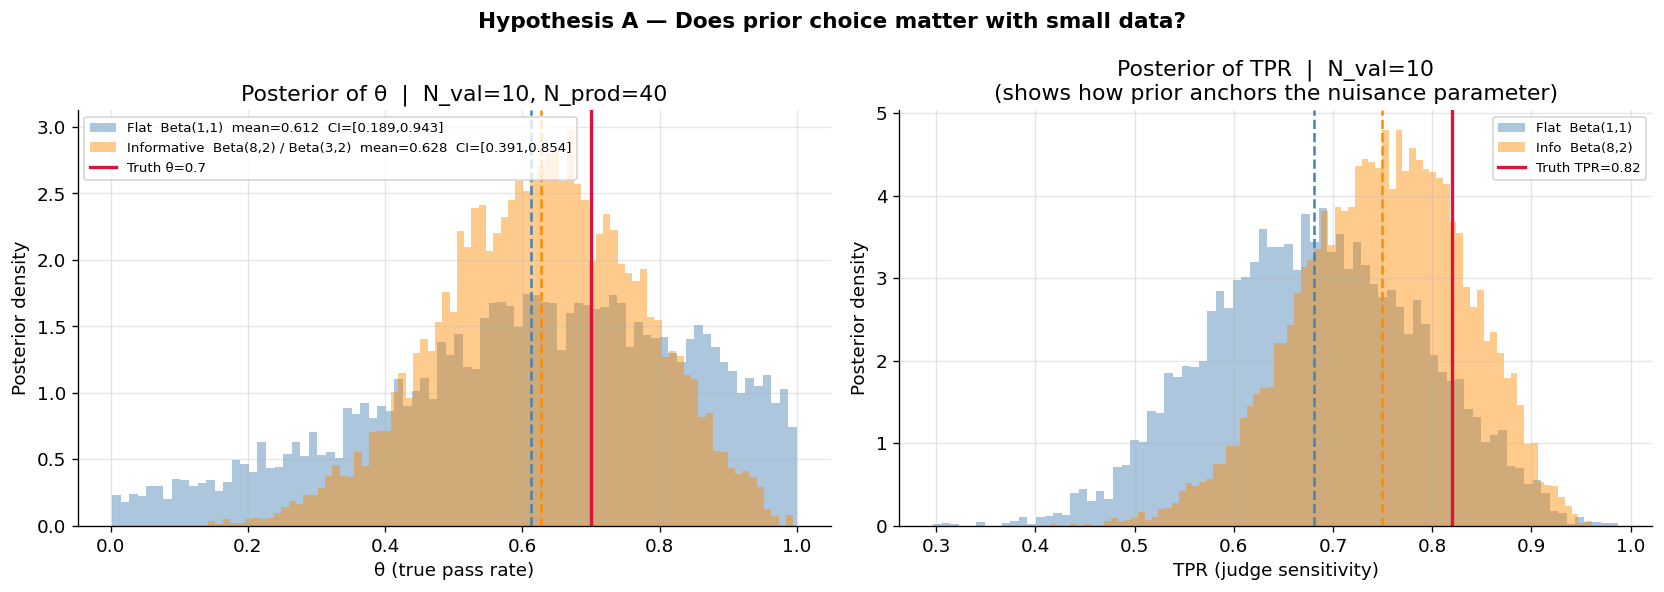

=== Hypothesis A: Results ===

  Flat prior     mean=0.612  89% CI=[0.189,0.943]  width=0.754  truth=0.7 ✓
  Info prior     mean=0.628  89% CI=[0.391,0.854]  width=0.464  truth=0.7 ✓

  CI width reduction: 0.754 → 0.464  (38.5% narrower)
  Hypothesis A: ✓ CONFIRMED — informative prior produces tighter posterior with small data.


In [16]:

# ── Hypothesis A: small data — flat vs informative prior ──────────────────────

def plot_comparison(ax, name_a, name_b, label_a, label_b, color_a, color_b, truth):
    """Overlay posterior of θ for two scenarios on one axis."""
    for name, label, color in [(name_a, label_a, color_a), (name_b, label_b, color_b)]:
        c, d, idata = results[name]
        samples = idata.posterior["theta"].values.ravel()
        lo, hi  = np.percentile(samples, [5.5, 94.5])
        mean    = samples.mean()
        ax.hist(samples, bins=80, density=True, color=color, alpha=0.45,
                label=f"{label}  mean={mean:.3f}  CI=[{lo:.3f},{hi:.3f}]")
        ax.axvline(mean, color=color, lw=1.5, ls="--")
    ax.axvline(truth, color="crimson", lw=2, ls="-", label=f"Truth θ={truth}")
    ax.set_xlabel("θ (true pass rate)")
    ax.set_ylabel("Posterior density")
    ax.legend(fontsize=8, loc="upper left")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Hypothesis A — Does prior choice matter with small data?",
             fontsize=13, fontweight="bold")

truth = SCENARIOS["small_flat"]["true_theta"]

# Left: θ posteriors overlaid
plot_comparison(
    axes[0],
    "small_flat", "small_informative",
    "Flat  Beta(1,1)", "Informative  Beta(8,2) / Beta(3,2)",
    "steelblue", "darkorange", truth,
)
axes[0].set_title("Posterior of θ  |  N_val=10, N_prod=40")

# Right: TPR posteriors — shows how the prior anchors the nuisance parameters
for name, label, color in [
    ("small_flat",        "Flat  Beta(1,1)",   "steelblue"),
    ("small_informative", "Info  Beta(8,2)",    "darkorange"),
]:
    c, d, idata = results[name]
    s = idata.posterior["tpr"].values.ravel()
    axes[1].hist(s, bins=80, density=True, color=color, alpha=0.45, label=label)
    axes[1].axvline(s.mean(), color=color, lw=1.5, ls="--")

axes[1].axvline(SCENARIOS["small_flat"]["true_tpr"], color="crimson", lw=2,
                label=f"Truth TPR={SCENARIOS['small_flat']['true_tpr']}")
axes[1].set_xlabel("TPR (judge sensitivity)")
axes[1].set_ylabel("Posterior density")
axes[1].set_title("Posterior of TPR  |  N_val=10\n(shows how prior anchors the nuisance parameter)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Plain-English verdict ──────────────────────────────────────────────────────
print("=== Hypothesis A: Results ===\n")
for name, label in [("small_flat", "Flat prior   "), ("small_informative", "Info prior   ")]:
    c, d, idata = results[name]
    s   = idata.posterior["theta"].values.ravel()
    lo, hi = np.percentile(s, [5.5, 94.5])
    width  = hi - lo
    inside = "✓" if lo <= c["true_theta"] <= hi else "✗"
    print(f"  {label}  mean={s.mean():.3f}  89% CI=[{lo:.3f},{hi:.3f}]  "
          f"width={width:.3f}  truth={c['true_theta']} {inside}")

c_flat = results["small_flat"][2].posterior["theta"].values.ravel()
c_info = results["small_informative"][2].posterior["theta"].values.ravel()
w_flat = np.diff(np.percentile(c_flat, [5.5, 94.5]))[0]
w_info = np.diff(np.percentile(c_info, [5.5, 94.5]))[0]
print(f"\n  CI width reduction: {w_flat:.3f} → {w_info:.3f}  ({(1-w_info/w_flat)*100:.1f}% narrower)")
verdict = "✓ CONFIRMED" if w_info < w_flat else "✗ NOT confirmed"
print(f"  Hypothesis A: {verdict} — informative prior produces tighter posterior with small data.")


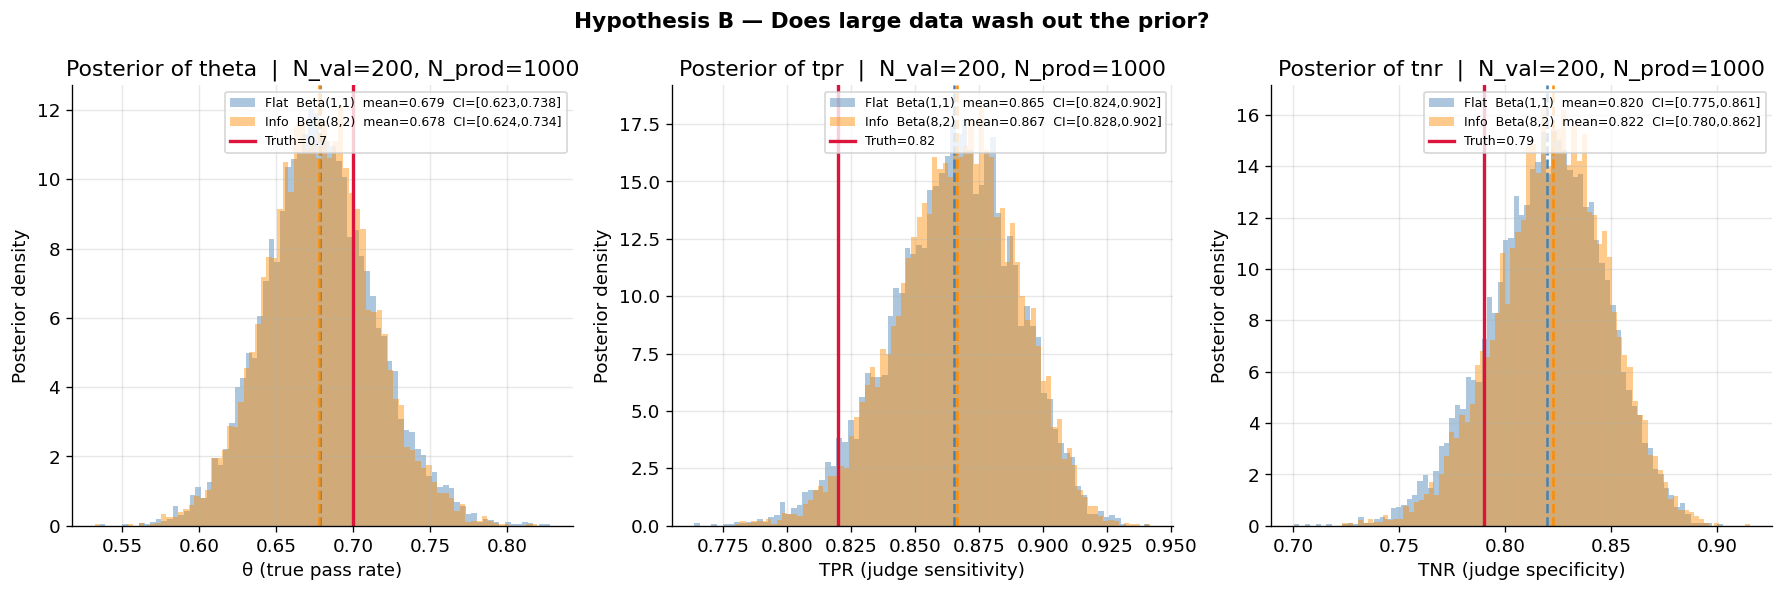

=== Full Summary Table ===

  Scenario              N_prod         Prior   mean θ            89% CI   width   truth  inside
  -------------------------------------------------------------------------------------
  small_flat                40          flat    0.612  [0.189, 0.943]   0.754    0.70       ✓
  small_informative         40   informative    0.628  [0.391, 0.854]   0.464    0.70       ✓
  large_flat              1000          flat    0.679  [0.623, 0.738]   0.115    0.70       ✓
  large_informative       1000   informative    0.678  [0.624, 0.734]   0.110    0.70       ✓

  Hypothesis B: ✓ CONFIRMED — posterior means differ by only 0.0006 with large data.
  The likelihood dominates: prior choice is irrelevant at N_prod=1000.


In [17]:

# ── Hypothesis B: large data — priors converge ────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Hypothesis B — Does large data wash out the prior?",
             fontsize=13, fontweight="bold")

truth = SCENARIOS["large_flat"]["true_theta"]

for param, ax, xlabel in [
    ("theta", axes[0], "θ (true pass rate)"),
    ("tpr",   axes[1], "TPR (judge sensitivity)"),
    ("tnr",   axes[2], "TNR (judge specificity)"),
]:
    true_val = {"theta": SCENARIOS["large_flat"]["true_theta"],
                "tpr":   SCENARIOS["large_flat"]["true_tpr"],
                "tnr":   SCENARIOS["large_flat"]["true_tnr"]}[param]

    for name, label, color in [
        ("large_flat",        "Flat  Beta(1,1)", "steelblue"),
        ("large_informative", "Info  Beta(8,2)", "darkorange"),
    ]:
        c, d, idata = results[name]
        s      = idata.posterior[param].values.ravel()
        lo, hi = np.percentile(s, [5.5, 94.5])
        ax.hist(s, bins=80, density=True, color=color, alpha=0.45,
                label=f"{label}  mean={s.mean():.3f}  CI=[{lo:.3f},{hi:.3f}]")
        ax.axvline(s.mean(), color=color, lw=1.5, ls="--")

    ax.axvline(true_val, color="crimson", lw=2, label=f"Truth={true_val}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Posterior density")
    ax.set_title(f"Posterior of {param}  |  N_val=200, N_prod=1000")
    ax.legend(fontsize=7.5)

plt.tight_layout()
plt.show()

# ── Summary table across all scenarios ────────────────────────────────────────
print("=== Full Summary Table ===\n")
print(f"  {'Scenario':<20s}  {'N_prod':>6s}  {'Prior':>12s}  "
      f"{'mean θ':>7s}  {'89% CI':>16s}  {'width':>6s}  {'truth':>6s}  {'inside':>6s}")
print("  " + "-" * 85)

all_scenarios = ["small_flat", "small_informative", "large_flat", "large_informative"]
for name in all_scenarios:
    c, d, idata = results[name]
    s      = idata.posterior["theta"].values.ravel()
    lo, hi = np.percentile(s, [5.5, 94.5])
    width  = hi - lo
    mean   = s.mean()
    truth  = c["true_theta"]
    inside = "✓" if lo <= truth <= hi else "✗"
    prior  = "flat" if c["theta_prior"] == (1,1) else "informative"
    print(f"  {name:<20s}  {c['N_prod']:>6d}  {prior:>12s}  "
          f"{mean:>7.3f}  [{lo:.3f}, {hi:.3f}]  {width:>6.3f}  {truth:>6.2f}  {inside:>6s}")

print()
# Hypothesis B verdict
s_flat = results["large_flat"][2].posterior["theta"].values.ravel()
s_info = results["large_informative"][2].posterior["theta"].values.ravel()
mean_diff = abs(s_flat.mean() - s_info.mean())
verdict = "✓ CONFIRMED" if mean_diff < 0.02 else "✗ NOT confirmed"
print(f"  Hypothesis B: {verdict} — posterior means differ by only {mean_diff:.4f} with large data.")
print(f"  The likelihood dominates: prior choice is irrelevant at N_prod=1000.")
